In [430]:
#Importing necessary packages
import numpy as np  
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from plotnine import * 
from janitor import *
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn import metrics
from sklearn.metrics import r2_score, mean_squared_error, ConfusionMatrixDisplay, classification_report
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.decomposition import PCA

In [431]:
#Loading the dataset
avocado = pd.read_csv('avocado.csv')
display(avocado.head())

#Checking for the information about the data
print(avocado.info())

#Checking for the shape of the data
shape = avocado.shape
print(f'The shape of the Avocado Dataset consist of {shape[1]} columns and {shape[0]} rows')

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,12/27/2015,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,12/20/2015,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,12/13/2015,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,12/6/2015,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,11/29/2015,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    18249 non-null  int64  
 1   Date          18249 non-null  object 
 2   AveragePrice  18249 non-null  float64
 3   Total Volume  18249 non-null  float64
 4   4046          18249 non-null  float64
 5   4225          18249 non-null  float64
 6   4770          18249 non-null  float64
 7   Total Bags    18249 non-null  float64
 8   Small Bags    18249 non-null  float64
 9   Large Bags    18249 non-null  float64
 10  XLarge Bags   18249 non-null  float64
 11  type          18249 non-null  object 
 12  year          18249 non-null  int64  
 13  region        18249 non-null  object 
dtypes: float64(9), int64(2), object(3)
memory usage: 1.9+ MB
None
The shape of the Avocado Dataset consist of 14 columns and 18249 rows


### Interrogating the Data & Data Cleaning

In [432]:
# Checking for duplicates
avocado_duplic = avocado.duplicated().sum()
print(f'The number of duplicates records are: {avocado_duplic}') #No duplicates so no need to drop duplicates

#Checking for missing values
avocado_missing = avocado.isna().sum()
print(f'The number of missing values in each columns are: \n{avocado_missing}')

#Cleaning the column names of the data
avocado1 = avocado.clean_names()
avocado1 = avocado1.rename(columns={'averageprice': 'average_price'})

#Dropping unnecessary column 'unnamed_0'
avocado1 = avocado1.drop('unnamed_0', axis = 1)
avocado1

The number of duplicates records are: 0
The number of missing values in each columns are: 
Unnamed: 0      0
Date            0
AveragePrice    0
Total Volume    0
4046            0
4225            0
4770            0
Total Bags      0
Small Bags      0
Large Bags      0
XLarge Bags     0
type            0
year            0
region          0
dtype: int64


,date,average_price,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region
0,12/27/2015,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,12/20/2015,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,12/13/2015,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,12/6/2015,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,11/29/2015,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18244,2/4/2018,1.63,17074.83,2046.96,1529.20,0.00,13498.67,13066.82,431.85,0.0,organic,2018,WestTexNewMexico
18245,1/28/2018,1.71,13888.04,1191.70,3431.50,0.00,9264.84,8940.04,324.80,0.0,organic,2018,WestTexNewMexico
18246,1/21/2018,1.87,13766.76,1191.92,2452.79,727.94,9394.11,9351.80,42.31,0.0,organic,2018,WestTexNewMexico
18247,1/14/2018,1.93,16205.22,1527.63,2981.04,727.01,10969.54,10919.54,50.00,0.0,organic,2018,WestTexNewMexico


In [433]:
#Checking for the statistical description of the data
avocado1.describe()

,average_price,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,year
count,18249.000000,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,18249.000000,18249.000000
mean,1.405978,8.506440e+05,2.930084e+05,2.951546e+05,2.283974e+04,2.396392e+05,1.821947e+05,5.433809e+04,3106.426507,2016.147899
std,0.402677,3.453545e+06,1.264989e+06,1.204120e+06,1.074641e+05,9.862424e+05,7.461785e+05,2.439660e+05,17692.894652,0.939938
min,0.440000,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,2015.000000
25%,1.100000,1.083858e+04,8.540700e+02,3.008780e+03,0.000000e+00,5.088640e+03,2.849420e+03,1.274700e+02,0.000000,2015.000000
50%,1.370000,1.073768e+05,8.645300e+03,2.906102e+04,1.849900e+02,3.974383e+04,2.636282e+04,2.647710e+03,0.000000,2016.000000
75%,1.660000,4.329623e+05,1.110202e+05,1.502069e+05,6.243420e+03,1.107834e+05,8.333767e+04,2.202925e+04,132.500000,2017.000000
max,3.250000,6.250565e+07,2.274362e+07,2.047057e+07,2.546439e+06,1.937313e+07,1.338459e+07,5.719097e+06,551693.650000,2018.000000


In [434]:
#Checking for the skewness of the data
avocado1.skew(numeric_only=True)

average_price     0.580303
total_volume      9.007687
4046              8.648220
4225              8.942466
4770             10.159396
total_bags        9.756072
small_bags        9.540660
large_bags        9.796455
xlarge_bags      13.139751
year              0.215339
dtype: float64

**Skew interpretation:** All the numerical columns in this dataset are positively skewed (right skewed). The xlarge_bags and 4770 are the highest skewed. The average price slightly skewed (almost normally distributed).

In [435]:
#Checking the counts of unique records in the region column
print(avocado1['region'].value_counts())

region
Albany                 338
Atlanta                338
BaltimoreWashington    338
Boise                  338
Boston                 338
BuffaloRochester       338
California             338
Charlotte              338
Chicago                338
CincinnatiDayton       338
Columbus               338
DallasFtWorth          338
Denver                 338
Detroit                338
GrandRapids            338
GreatLakes             338
HarrisburgScranton     338
HartfordSpringfield    338
Houston                338
Indianapolis           338
Jacksonville           338
LasVegas               338
LosAngeles             338
Louisville             338
MiamiFtLauderdale      338
Midsouth               338
Nashville              338
NewOrleansMobile       338
NewYork                338
Northeast              338
NorthernNewEngland     338
Orlando                338
Philadelphia           338
PhoenixTucson          338
Pittsburgh             338
Plains                 338
Portland             

In [436]:
# Converting the date column from object to datetime and extracting month
avocado1['date'] = pd.to_datetime(avocado1['date'])
avocado1['month'] = avocado1['date'].dt.month
avocado1.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           18249 non-null  datetime64[ns]
 1   average_price  18249 non-null  float64       
 2   total_volume   18249 non-null  float64       
 3   4046           18249 non-null  float64       
 4   4225           18249 non-null  float64       
 5   4770           18249 non-null  float64       
 6   total_bags     18249 non-null  float64       
 7   small_bags     18249 non-null  float64       
 8   large_bags     18249 non-null  float64       
 9   xlarge_bags    18249 non-null  float64       
 10  type           18249 non-null  object        
 11  year           18249 non-null  int64         
 12  region         18249 non-null  object        
 13  month          18249 non-null  int32         
dtypes: datetime64[ns](1), float64(9), int32(1), int64(1), object(2)
memory

--------------------------------------------------------------------------------------------------------------------------------------------------------------------


## Summary and Insights from Data cleaning and Exploration

- The data was collected from 54 regions in the United States.
- The dataset contained 14 columns and 18249 records with no missing and duplicate entries/values. 
- The date column was converted to datetime format.
- The column names were cleaned using the .clean_names() function in janitor and the unnecessary 'unnamed:0' column was dropped.
- The month column was created by extracting the month from the date(feature engineering). Column "averageprice" was also renamed to average_price to be in the order of proper column naming. 
- All the numerical columns in this dataset are positively skewed (right skewed). The xlarge_bags and 4770 are the highest skewed. The average price slightly skewed (almost normally distributed).


## Data Exploration

type
conventional    9126
organic         9123
Name: count, dtype: int64


,type,average_price
0,conventional,1.158040
1,organic,1.653999


,type,total_volume
0,conventional,1.508722e+10
1,organic,4.361817e+08


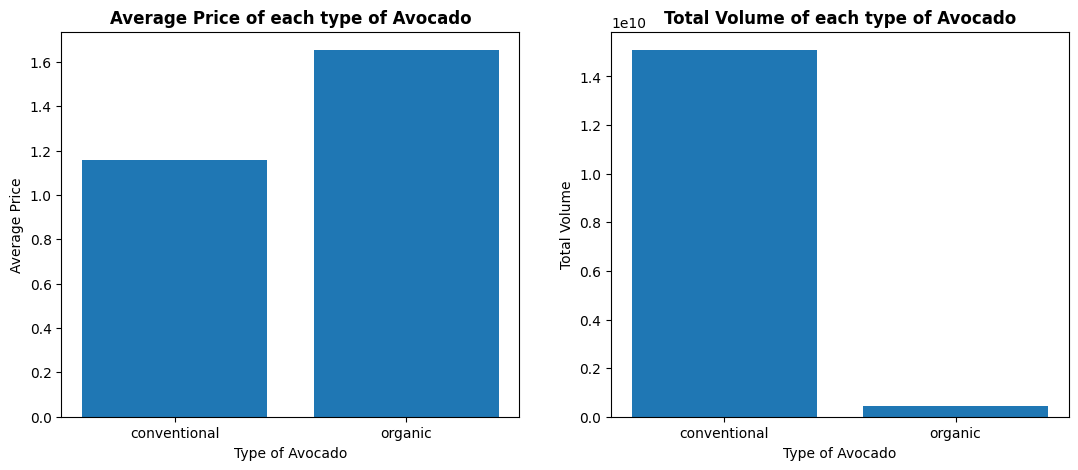

In [437]:
#Checking the counts of avocados
type_avocad = avocado1['type'].value_counts()
print(type_avocad)

#The variable 'type_price_avocad' answers the question: Which type of avocado is cheaper?
type_price_avocad = avocado1.groupby(['type'])['average_price'].mean().reset_index()
display(type_price_avocad)

#The variable 'type_volume_avocad' answers the question: Which type of avocado is the most available i.e. the most volume?
type_volume_avocad = avocado1.groupby(['type'])['total_volume'].sum().reset_index()
display(type_volume_avocad)

#Visualizing the Average Price of each type of Avocado
fig, ax = plt.subplots(1, 2, figsize =(13, 5))
ax[0].bar(type_price_avocad['type'], type_price_avocad['average_price'])
ax[0].set_xlabel('Type of Avocado')
ax[0].set_ylabel('Average Price')
ax[0].set_title('Average Price of each type of Avocado', fontweight = 'bold')

#Visualizing the Total Volume of each type of Avocado
ax[1].bar(type_volume_avocad['type'], type_volume_avocad['total_volume'])
ax[1].set_xlabel('Type of Avocado')
ax[1].set_ylabel('Total Volume')
ax[1].set_title('Total Volume of each type of Avocado', fontweight = 'bold')
plt.show()

**Plot Interpretation**: This is a grid plot of comparing the two types of avocados based on their average prices and purchase.   
Organic avocados are more expensive than conventional avocados, while conventional avocados are purchased more frequently than organic avocados.

In [438]:
#The variable 'avo_year_month_price' displays the trend of the type of avocado average price each month and year. 
avo_year_month_price = avocado1.groupby(['date', 'type'])['average_price'].mean().reset_index()
avo_year_month_price.head()

,date,type,average_price
0,2015-01-04,conventional,1.009630
1,2015-01-04,organic,1.592963
2,2015-01-11,conventional,1.111296
3,2015-01-11,organic,1.630000
4,2015-01-18,conventional,1.133519


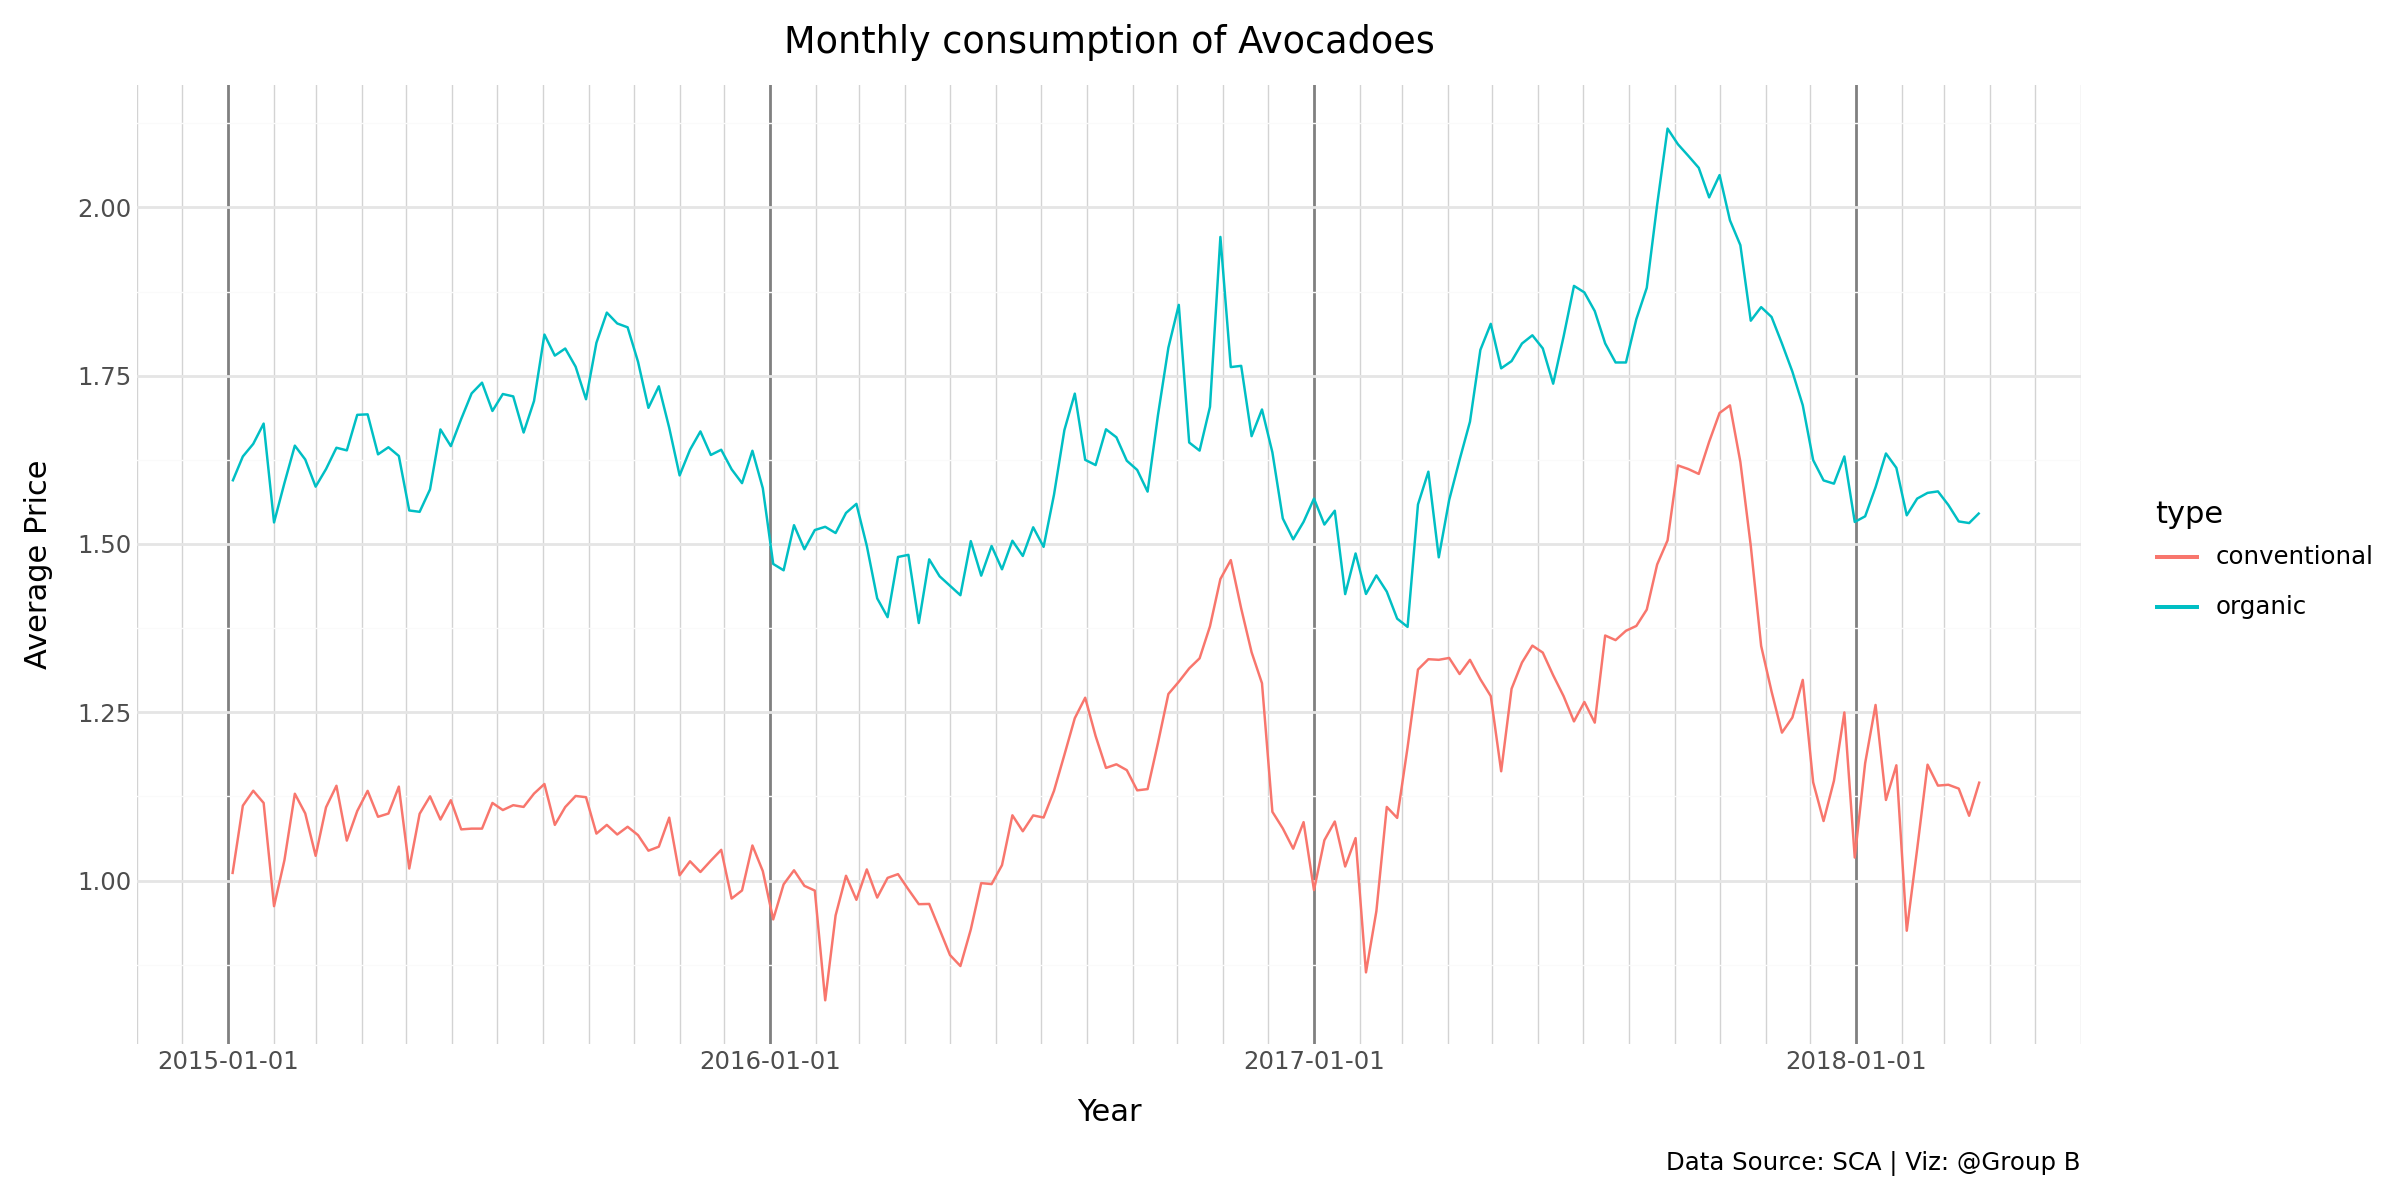

In [439]:
#Visualising 'avo_year_month_price'
(ggplot(avo_year_month_price, aes('date', 'average_price', color = 'type')) + geom_line()
 + labs(x = 'Year', 
        y = 'Average Price',
        title= 'Monthly consumption of Avocadoes',
        caption= 'Data Source: SCA | Viz: @Group B')
+ scale_x_date(date_breaks='1 year', date_minor_breaks='1 month')
+ theme_minimal()
+ theme(panel_grid_minor_x=element_line(color = '#d3d3d3'), panel_grid_major_x=element_line(color='grey'), figure_size=(12, 6)))

**Plot Interpretation**:   
*Please Note*: Data collection ended after the first quarter of 2018.  
This plot displays the trend of the both type of avocado prices each month and year. The average price peaks around September-October every year.


In [440]:
#The variable 'avo_year_price' answers the question: What is the average price of avocados each year? 
avo_year_price = avocado1.groupby('year')['average_price'].mean().reset_index()
avo_year_price

,year,average_price
0,2015,1.375590
1,2016,1.338640
2,2017,1.515128
3,2018,1.347531


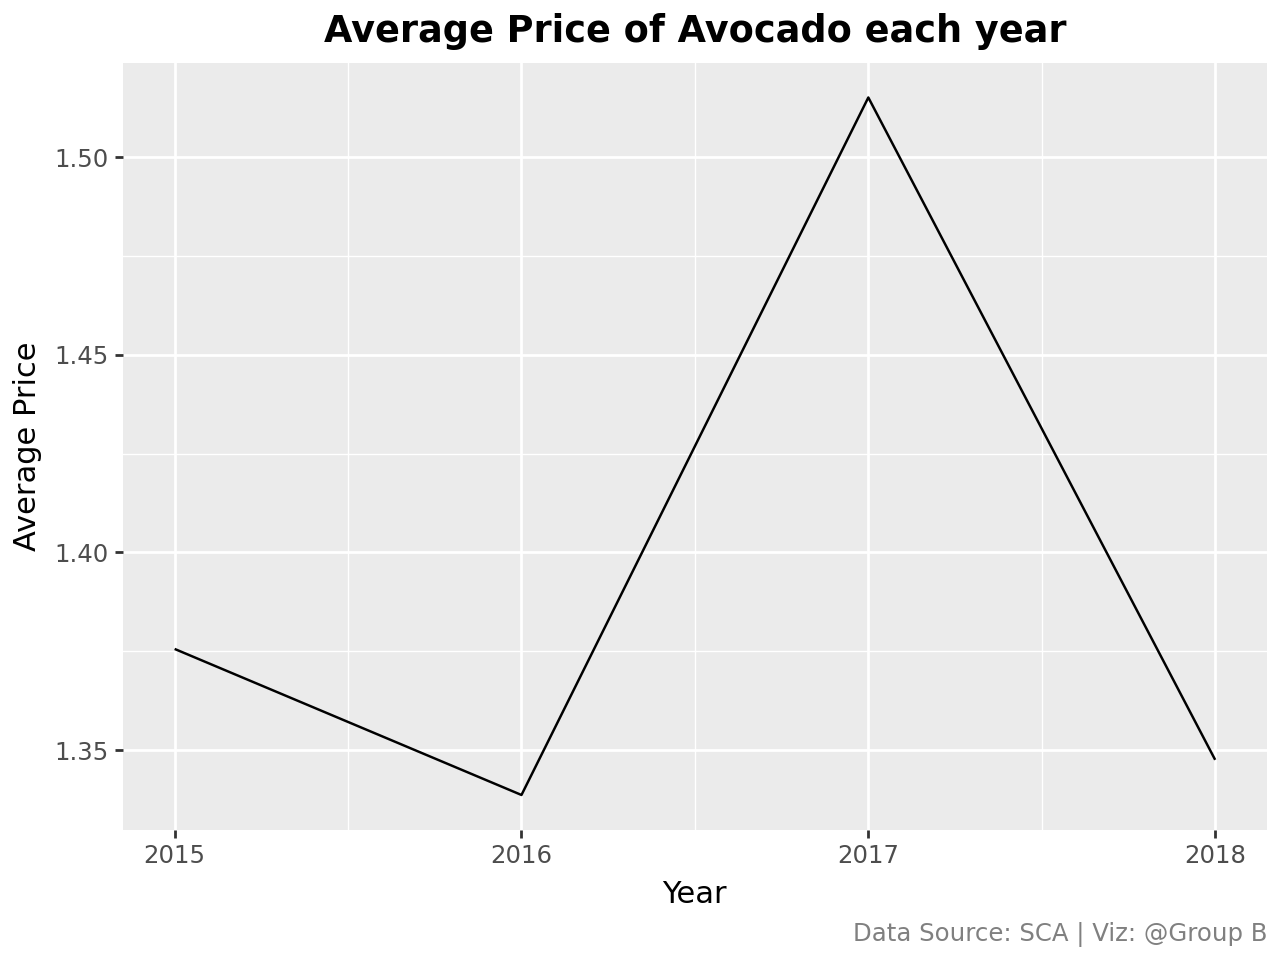

In [441]:
(ggplot(avo_year_price, aes('year', 'average_price')) + geom_line()
 + labs(x = 'Year', 
        y = 'Average Price',
        title= 'Average Price of Avocado each year',
        caption= 'Data Source: SCA | Viz: @Group B')
+ theme(plot_title=element_text(weight='bold'), plot_caption=element_text(color='grey')))

**Plot Interpretation:** This plot visualizes the year that avocado was most expensive. The average price of avocados reduced in 2016 and rose to the highest in 2017 at a mean average price of about $1.51.

In [442]:
#The variable 'avo_date_vol_con' displays the trend of avocado purchase each month and year. 
avo_date_vol_con = avocado1.groupby(['date'])['total_volume'].sum().reset_index()
avo_date_vol_con.head()

,date,total_volume
0,2015-01-04,8.467434e+07
1,2015-01-11,7.855581e+07
2,2015-01-18,7.838878e+07
3,2015-01-25,7.646628e+07
4,2015-02-01,1.194532e+08


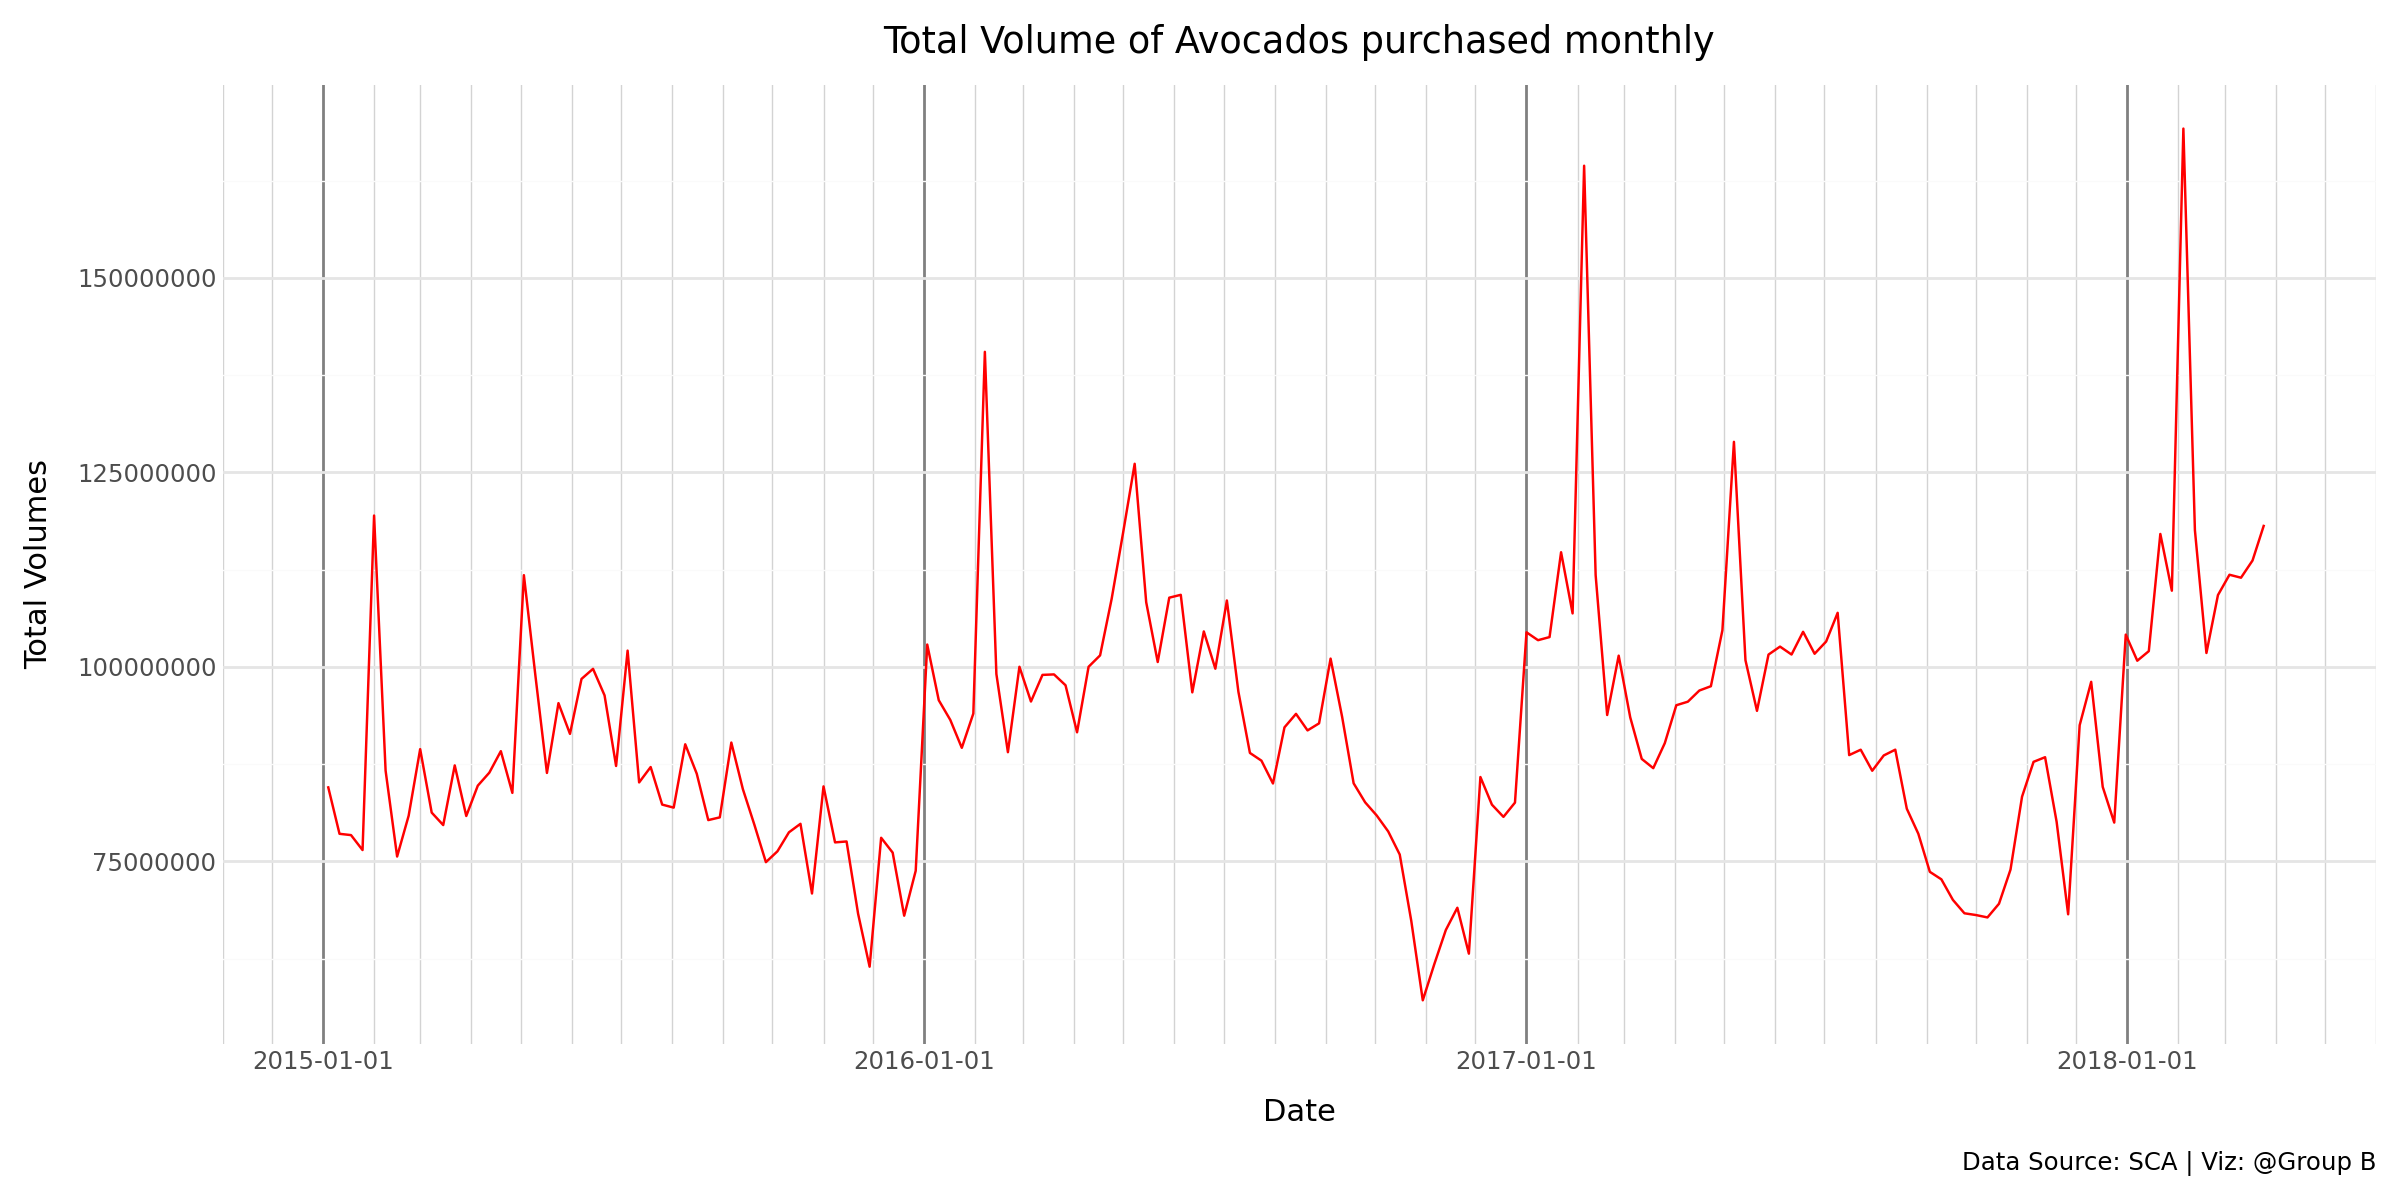

In [443]:
#Visualising 'avo_year_month_price'
(ggplot(avo_date_vol_con, aes('date', 'total_volume')) + geom_line(color = 'red')
 + labs(x = 'Date', 
        y = 'Total Volumes',
        title= 'Total Volume of Avocados purchased monthly',
        caption= 'Data Source: SCA | Viz: @Group B')
+ scale_x_date(date_breaks='1 year', date_minor_breaks='1 month')
+ theme_minimal()
+ theme(panel_grid_minor_x=element_line(color = '#d3d3d3'), panel_grid_major_x=element_line(color='grey'), figure_size=(12, 6)))

**Plot Interpretation:** From this plot, there is a trend and seasonality. Avocados are purchased mostly early in the second month and in the fifth month. Then the purchase drops during the late part of the year (September - December).

In [444]:
#The variable 'avo_year_vol' answers the question: What is the total volume of avocados purchased each year? 
avo_year_vol = avocado1.groupby(['year'])['total_volume'].sum().reset_index()
avo_year_vol.head()

av_2017 = avo_year_vol[avo_year_vol['year']== 2017]

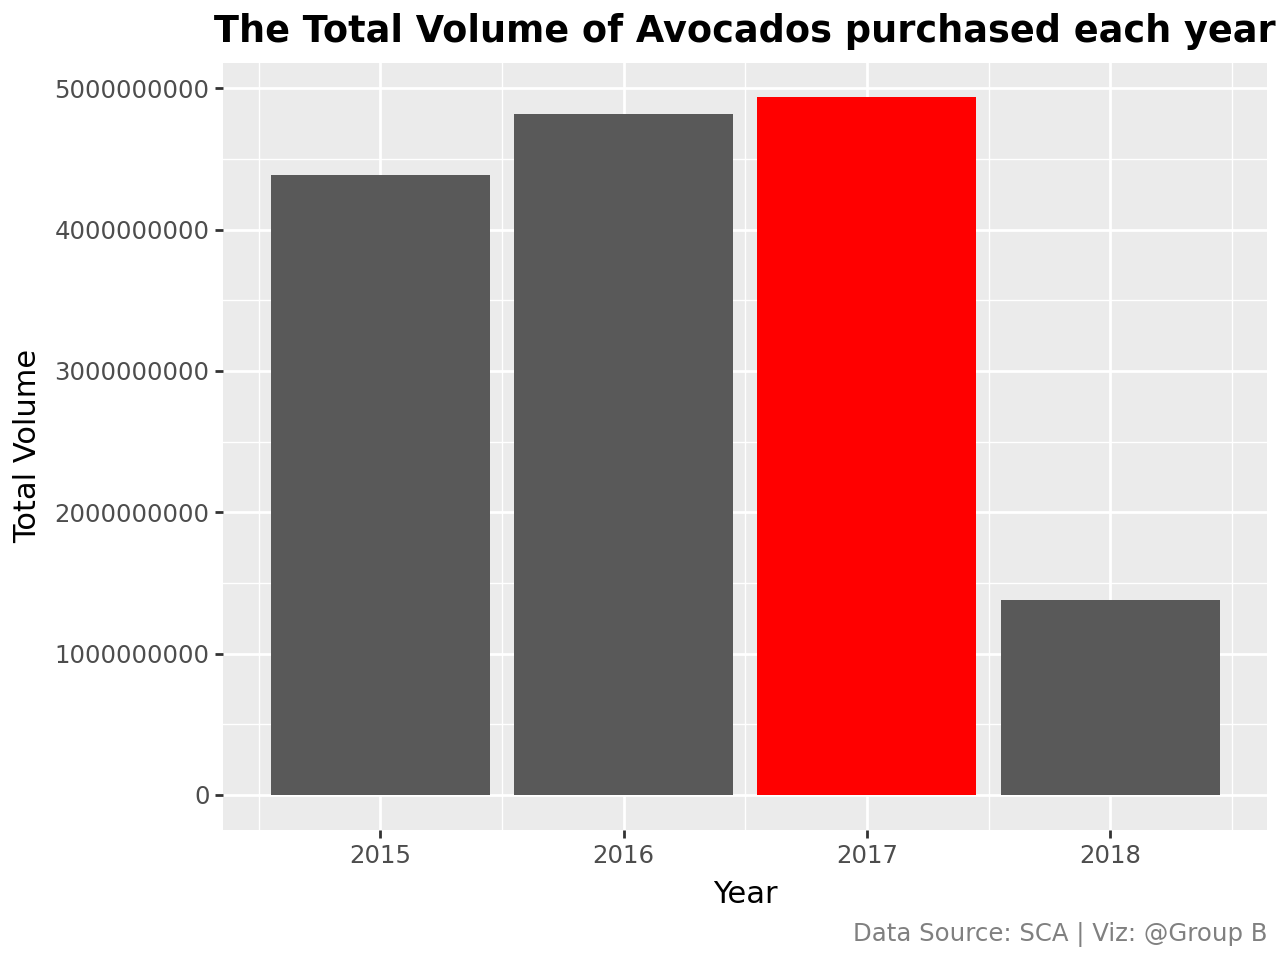

In [445]:
(ggplot(avo_year_vol, aes('year', 'total_volume')) + geom_col() + geom_col(av_2017, aes('year', 'total_volume'), fill = 'red')
 + labs(x = 'Year', 
        y = 'Total Volume',
        title= 'The Total Volume of Avocados purchased each year',
        caption= 'Data Source: SCA | Viz: @Group B')
+ theme(plot_title=element_text(weight='bold'), plot_caption=element_text(color='grey')))

**Plot Interpretation:** This is a barplot that shows the total volume of avovados purchased each year. Avocados were more purchased in 2017.

In [446]:
#The variable 'avo_year_month_vol' answers the question: Which month(s) is/are avocados purchased the most? 
avo_year_month_vol = avocado1.groupby(['month', 'year'])['total_volume'].sum().reset_index()
avo_year_month_vol.head()


,month,year,total_volume
0,1,2015,3.180852e+08
1,1,2016,4.754058e+08
2,1,2017,5.333330e+08
3,1,2018,4.297071e+08
4,2,2015,3.626376e+08


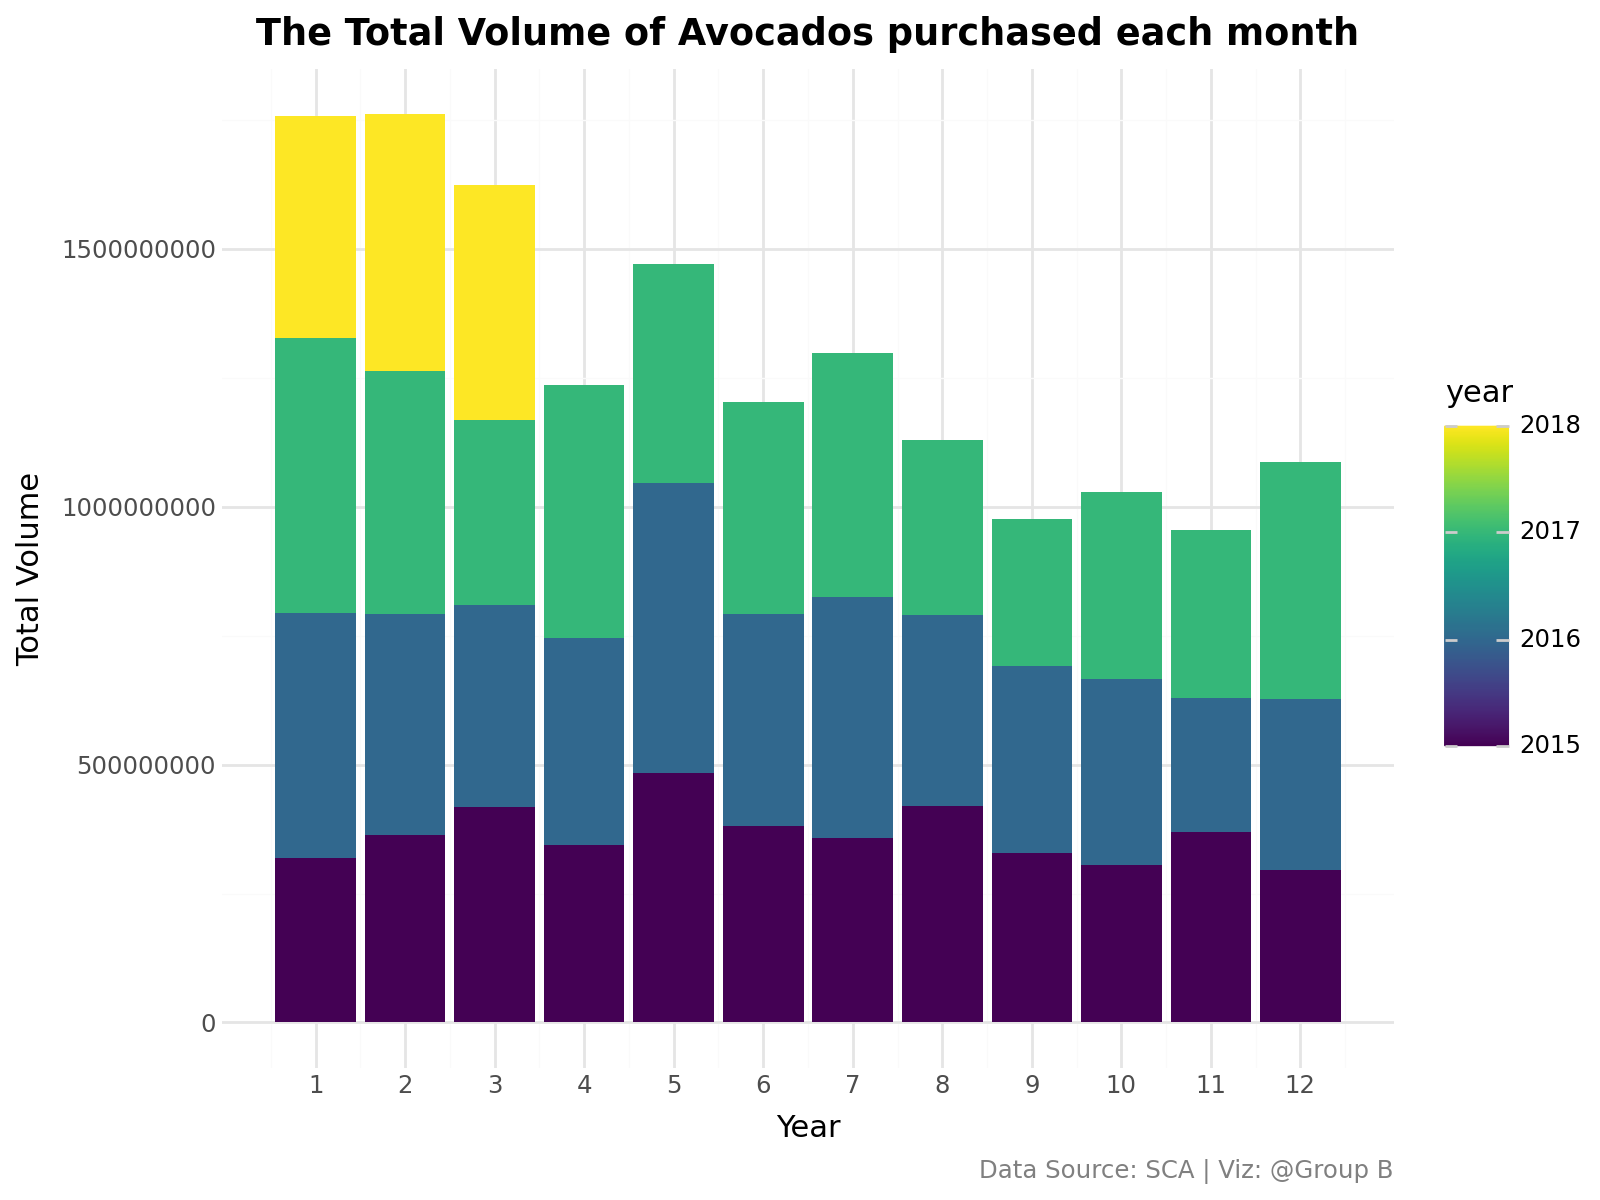

In [447]:
#Visualizing the month(s) avocados are bought the most?
(ggplot(avo_year_month_vol, aes('month', 'total_volume', fill = 'year')) + geom_col() 
 + labs(x = 'Year', 
        y = 'Total Volume',
        title= 'The Total Volume of Avocados purchased each month',
        caption= 'Data Source: SCA | Viz: @Group B')
+ scale_x_continuous(breaks=range(1, 13, 1))
+ theme_minimal()
+ theme(plot_title=element_text(weight='bold'), plot_caption=element_text(color='grey'), figure_size=(8,6)))

**Plot Interpretation:** This is a stacked barplot that shows the total volume of avovados purchased each month. In total, Avocados were purchased the most in May (ignoring the yellow stack bar), the July and February.

In [448]:
#The variable 'region_price' answers the question 'What region had the average highest price?'
region_price = avocado1.groupby(['region'])['average_price'].mean().sort_values(ascending = False).reset_index()

#The variable 'region_volume' answers the question 'Which region consumed the most avocados?'
region_volume = avocado1.groupby(['region', 'type'])['total_volume'].sum().sort_values(ascending = False).reset_index()
max = region_price[region_price['average_price'] == region_price['average_price'].max()]



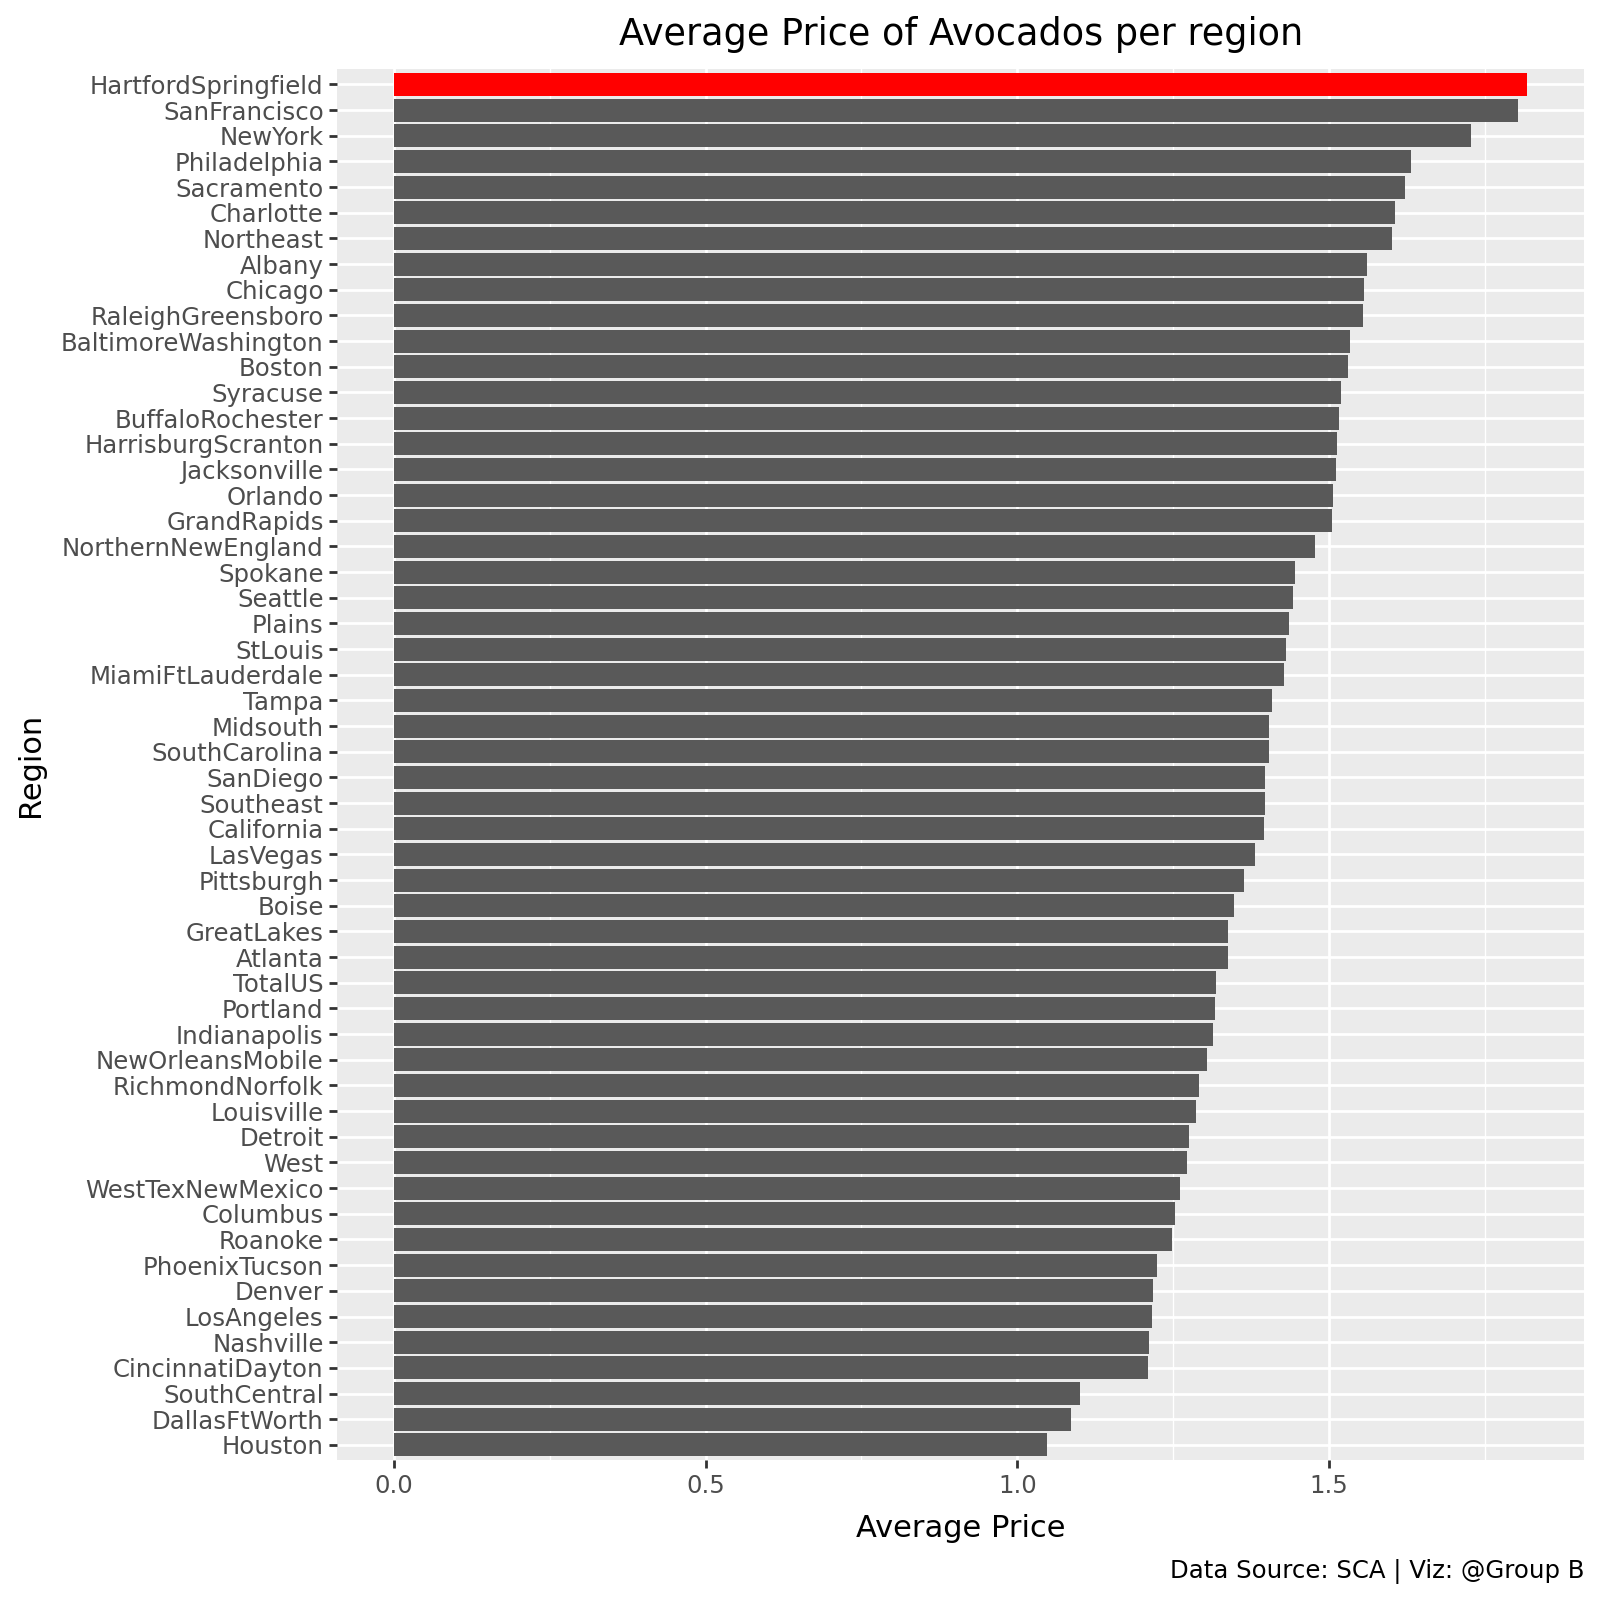

In [449]:
(ggplot(region_price, aes('reorder(region, average_price)', 'average_price')) + geom_col()
 + geom_col(max, aes('region', 'average_price'), fill = 'red')
 + coord_flip()
 + labs(x = 'Region', 
        y = 'Average Price',
        title= 'Average Price of Avocados per region',
        caption= 'Data Source: SCA | Viz: @Group B')
 + theme(figure_size=(8, 8)))



**Plot Interpretation:** This is a barplot of the region against the Average Price of Avocados purchased. Avocadoes are more expensive at HartfordSpringield and SanFrancisco while avocado is cheapest at Houston.

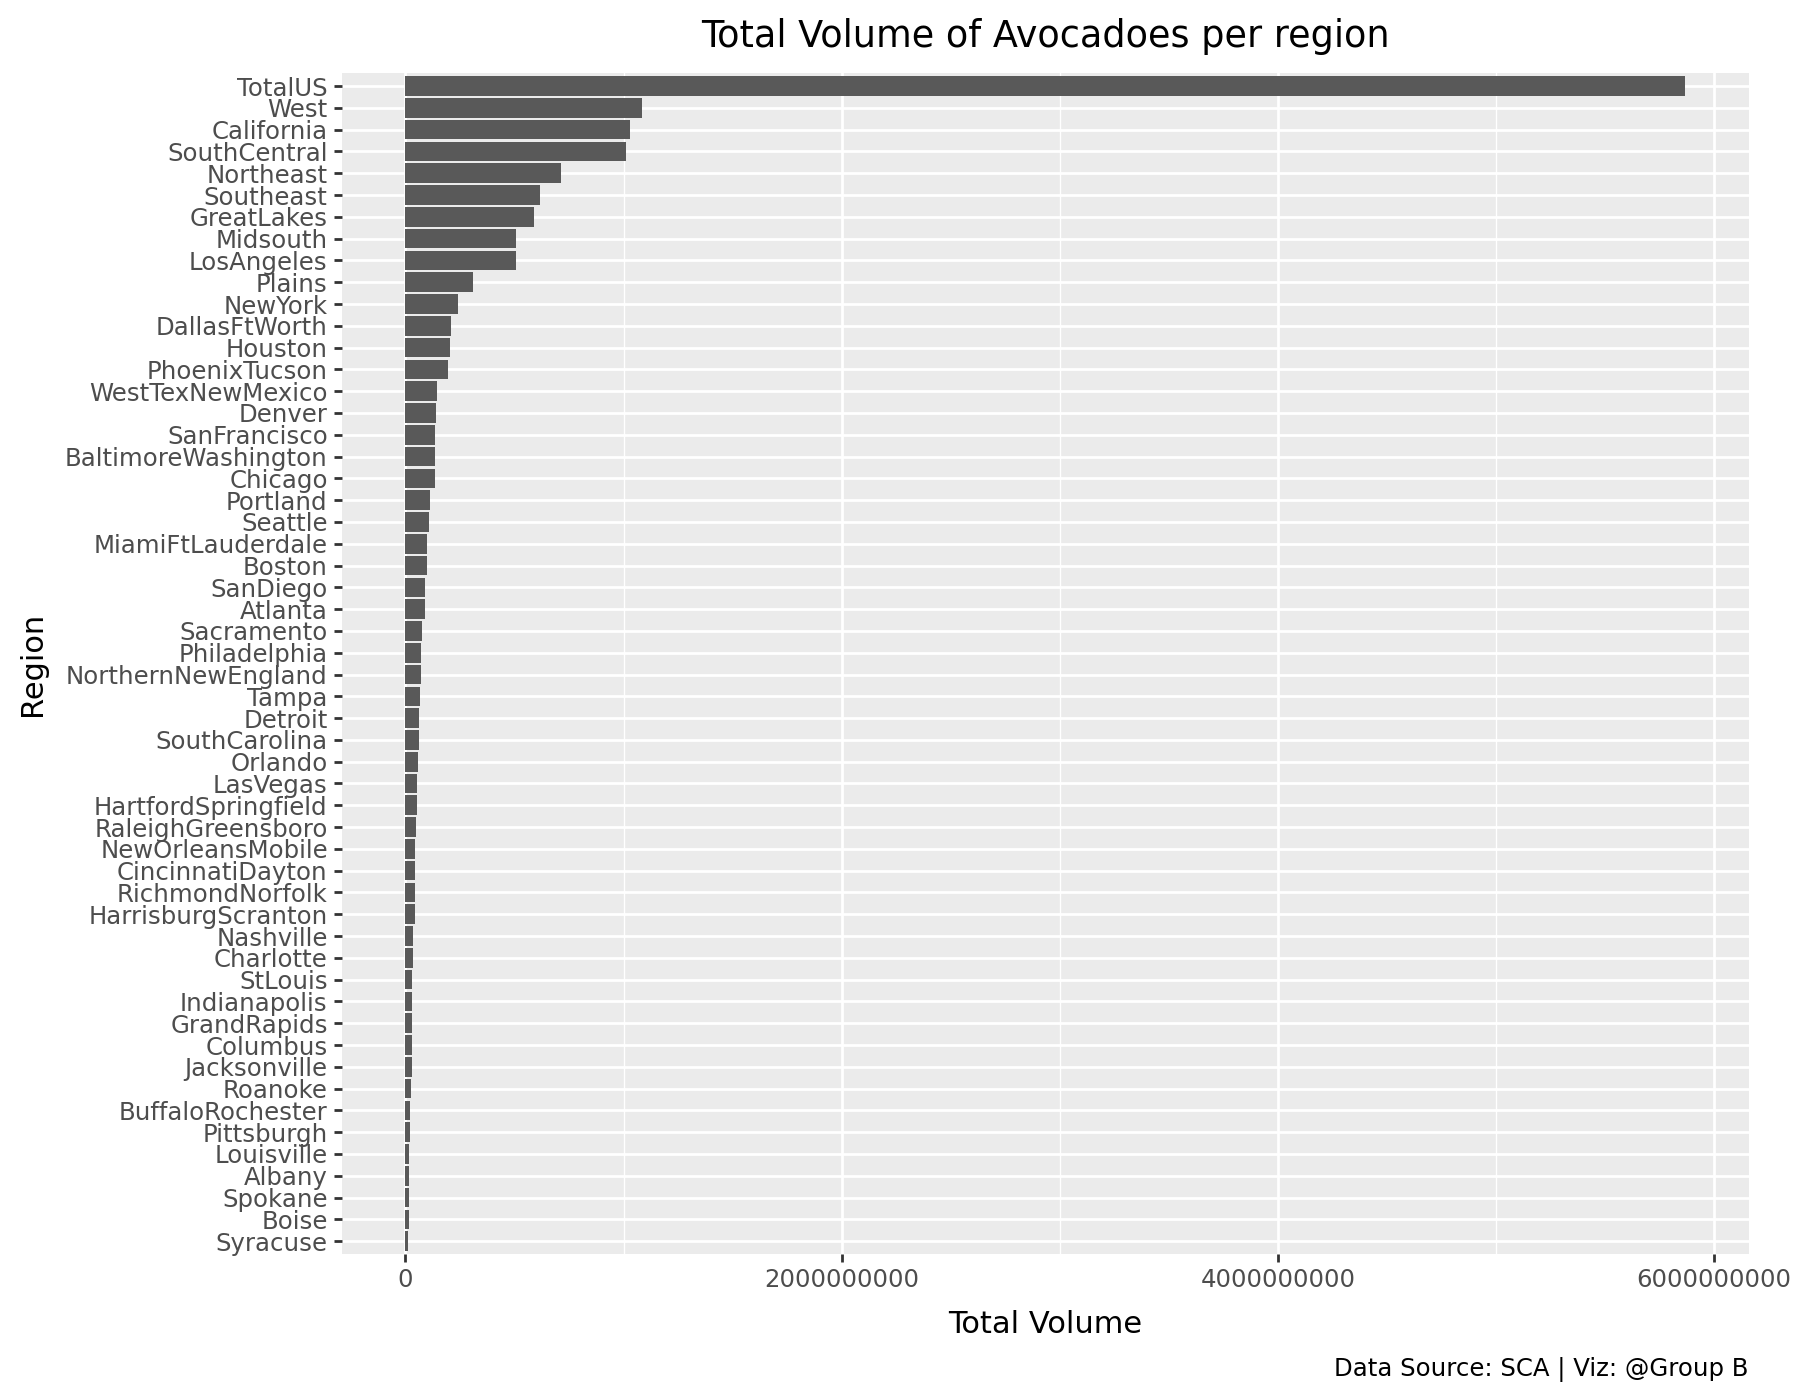

In [450]:
(ggplot(region_volume, aes('reorder(region, total_volume)', 'total_volume')) + geom_col()
 + coord_flip()
 + labs(x = 'Region', 
        y = 'Total Volume',
        title= 'Total Volume of Avocadoes per region',
        caption= 'Data Source: SCA | Viz: @Group B')
 + theme(figure_size=(9, 7)))

**Plot Interpretation:** This is a barplot of the region against the Total volumes purchased. The TotalUS and the West purchase the most avocados in the United States. Syracuse purchase the least number of avocados.

In [451]:
#Checking for the correlation coefficient
num_cols = avocado1.select_dtypes([int, float])
corr_avocad = num_cols.corr()

display(corr_avocad)

print(f'The highest correlated feature to Average price is {corr_avocad['average_price'].drop('average_price').abs().idxmax()}: -{corr_avocad['average_price'].drop('average_price').abs().max():.2f}')
print(f'The least correlated feature to Average price is {corr_avocad['average_price'].drop('average_price').abs().idxmin()}: {corr_avocad['average_price'].drop('average_price').abs().min():.2f}')

,average_price,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,year,month
average_price,1.000000,-0.192752,-0.208317,-0.172928,-0.179446,-0.177088,-0.174730,-0.172940,-0.117592,0.093197,0.162409
total_volume,-0.192752,1.000000,0.977863,0.974181,0.872202,0.963047,0.967238,0.880640,0.747157,0.017193,-0.024689
4046,-0.208317,0.977863,1.000000,0.926110,0.833389,0.920057,0.925280,0.838645,0.699377,0.003353,-0.025803
4225,-0.172928,0.974181,0.926110,1.000000,0.887855,0.905787,0.916031,0.810015,0.688809,-0.009559,-0.022108
4770,-0.179446,0.872202,0.833389,0.887855,1.000000,0.792314,0.802733,0.698471,0.679861,-0.036531,-0.033424
total_bags,-0.177088,0.963047,0.920057,0.905787,0.792314,1.000000,0.994335,0.943009,0.804233,0.071552,-0.022724
small_bags,-0.174730,0.967238,0.925280,0.916031,0.802733,0.994335,1.000000,0.902589,0.806845,0.063915,-0.023126
large_bags,-0.172940,0.880640,0.838645,0.810015,0.698471,0.943009,0.902589,1.000000,0.710858,0.087891,-0.020187
xlarge_bags,-0.117592,0.747157,0.699377,0.688809,0.679861,0.804233,0.806845,0.710858,1.000000,0.081033,-0.012969
year,0.093197,0.017193,0.003353,-0.009559,-0.036531,0.071552,0.063915,0.087891,0.081033,1.000000,-0.177050


The highest correlated feature to Average price is 4046: -0.21
The least correlated feature to Average price is year: 0.09


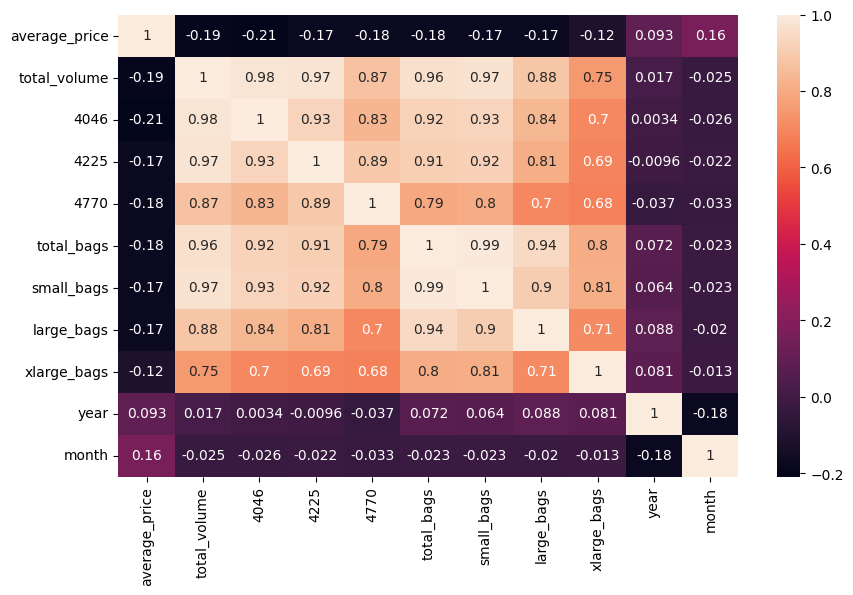

In [452]:
#Heatmap to visualise
plt.figure(figsize=(10, 6))
sns.heatmap(corr_avocad, annot=True)
plt.show()

**Plot Interpretation:** The independent variables are highly correlated with each other. There is barely any linear relationship between the independent and dependent variable. However the type of avocado has a correlation value of 0.61 with average_price.

## Summary of Data Exploration.
- There are two types of Avocadoes, Organic and Conventional avocados. Organic avocados are more expensive and the least purchased.  
- Avocados were most expensive in 2017 and purchased the most in 2017 as shown on the bar and line plot. We suggest that they were expensive because: 
    - Avocado harvesting reduced maybe due poor weather conditions or pest eating it.   
    - People purchased it alot in 2017 at a high price causing the average price to increase.  
- From the trend plot and stacked bar of the monthly purchase of avocado, avocados were purchased more in February, May and July. After research, we discovered: 
    - they are high in February due to the Super Bowl, the popular guacamole snack is consumed during the superbowl.
    - they are high in May due to the Cinco de Mayo, a holiday for the making of mexican dish and guacamole snack.
    - they are high in July due to the Independence day celebration,and the National Avocado day in July 31st. 
- Avocados are most expensive in HartfortSpringfield region. We suggest that it is due to logistics from harvesting region. Harvesting regions are California, Mexico, Florida. Avocados are cheapest in Houston which borders Mexico. 
- The TotalUS and the West purchase the most avocadoes. Although the TotalUS sounds odd, the West contains California which is an Avocado harvesting region.

## Data Preprocessing

In [453]:
#Encoding the type column 
le = LabelEncoder()
avocado1['type_no'] = le.fit_transform(avocado1['type'])  #0 - conventional; 1 - organic

#Encoding the region column
avocado1['region'] = le.fit_transform(avocado1['region'])

#selecting numerical columns
num_cols = avocado1.select_dtypes([int, float])
corr_avocad = num_cols.corr()

display(corr_avocad) 
print(f'Type has a correlation coefficient of {corr_avocad['type_no'].drop('type_no').max():2f} with Average Price')

,average_price,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,year,region,month,type_no
average_price,1.000000,-0.192752,-0.208317,-0.172928,-0.179446,-0.177088,-0.174730,-0.172940,-0.117592,0.093197,-0.011716,0.162409,0.615845
total_volume,-0.192752,1.000000,0.977863,0.974181,0.872202,0.963047,0.967238,0.880640,0.747157,0.017193,0.174176,-0.024689,-0.232434
4046,-0.208317,0.977863,1.000000,0.926110,0.833389,0.920057,0.925280,0.838645,0.699377,0.003353,0.192073,-0.025803,-0.225819
4225,-0.172928,0.974181,0.926110,1.000000,0.887855,0.905787,0.916031,0.810015,0.688809,-0.009559,0.145726,-0.022108,-0.232289
4770,-0.179446,0.872202,0.833389,0.887855,1.000000,0.792314,0.802733,0.698471,0.679861,-0.036531,0.095252,-0.033424,-0.210027
total_bags,-0.177088,0.963047,0.920057,0.905787,0.792314,1.000000,0.994335,0.943009,0.804233,0.071552,0.175256,-0.022724,-0.217788
small_bags,-0.174730,0.967238,0.925280,0.916031,0.802733,0.994335,1.000000,0.902589,0.806845,0.063915,0.164702,-0.023126,-0.220535
large_bags,-0.172940,0.880640,0.838645,0.810015,0.698471,0.943009,0.902589,1.000000,0.710858,0.087891,0.198768,-0.020187,-0.193177
xlarge_bags,-0.117592,0.747157,0.699377,0.688809,0.679861,0.804233,0.806845,0.710858,1.000000,0.081033,0.082281,-0.012969,-0.175483
year,0.093197,0.017193,0.003353,-0.009559,-0.036531,0.071552,0.063915,0.087891,0.081033,1.000000,-0.000055,-0.177050,-0.000032


Type has a correlation coefficient of 0.615845 with Average Price


# Part 1: Linear Regression

In [454]:
#Selecting the independent and dependent variables
X = avocado1[['type_no', 'total_volume']] 
y = avocado1['average_price']

#Splitting the data into 70% training and 30% test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Initiating the Linear Regression model_1 & fit
model_1 = LinearRegression()
model_1.fit(X_train, y_train)

#Checking for the coefficient and intercept of the model
model_1_intercept = model_1.intercept_
model_1_coefficient = model_1.coef_  

print(model_1_coefficient)
print(model_1_intercept)

# Creating a dataframe to show the coefficient better
miles_df = pd.DataFrame(model_1_coefficient, X.columns, ['Coefficient'])
miles_df

[ 4.89377587e-01 -6.18869940e-09]
1.1656409756082462


,Coefficient
type_no,4.893776e-01
total_volume,-6.188699e-09


Why the type and total volume variables were used.
This is because the Type volumn has a good linear relationship with the target variable. Although the total volume doesn't really have a good relationship with the target variable, it summarises most of the other columns (4046, 4225, 4770, total_bags)

### Formula prediction for model_1
#### average_price = 1.165 + 4.893776e-01 * type_no - 6.188699e-09 * total_volume

### Interpretation of model_1  
For every unit increase in the type of avocado (type_no), keeping the other variable (total_volume) constant, the average price increases by 4.893776e-01 and for every unit increase in the total volume of avocados purchased (total_volume) keeping the other variable constant (type_no), the average price increases by 6.188699e-09.

In [455]:
# Predicting the model with the training dataset
predicted_avg_price = model_1.predict(X_train)

#Evaluating the scores of model_2 on the training data predicted
mse_l = mean_squared_error(y_train, predicted_avg_price)
rmse_l = np.sqrt(mse_l)

r2_score = r2_score(y_train, predicted_avg_price)

#Changing it to a Dataframe for neat work
scores_df = pd.DataFrame([rmse_l, r2_score], columns= ['Evaluation Metrics Model1'], index = ['rmse', 'r2_score'])
display(scores_df)

residuals = y_train - predicted_avg_price

residuals_df = pd.DataFrame({'residuals': residuals, 
                               'predicted': predicted_avg_price})

,Evaluation Metrics Model1
rmse,0.315851
r2_score,0.386083


### Interpretation of Evaluation Metrics for Model 2  
The model explains 38.6% of the variation which means it is a poor fit. The model is off, on average, by about 0.32 which is not bad.  


##### Residual Plot  

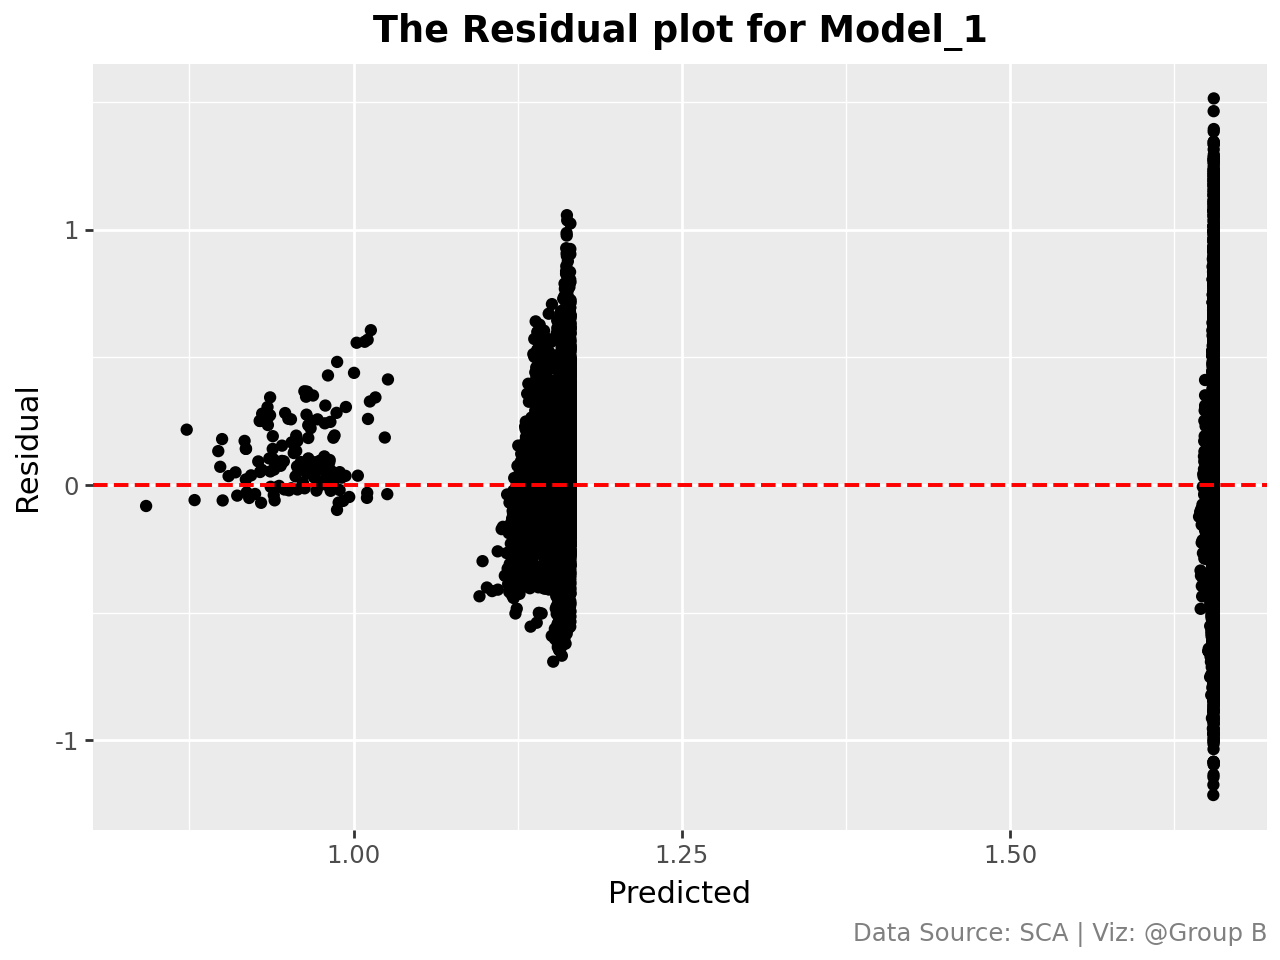

In [456]:
(ggplot(residuals_df, aes('predicted', 'residuals')) + geom_point()
 + geom_hline(aes(yintercept = 0), color = 'red', linetype = '--', size = 0.8)
 + labs(x = 'Predicted', 
        y = 'Residual',
        title= 'The Residual plot for Model_1',
        caption= 'Data Source: SCA | Viz: @Group B')
+ theme(plot_title=element_text(weight='bold'), plot_caption=element_text(color='grey')))

**Plot Interpretation:** The plot of the residual and predicted value shows a pattern (slightly funnel-shaped) initially, indicating a non-constant variance (heteroscedasticity). This violates one of the assumptions of linear regression which is homoscedasticity. 

# Part 1: Time Series Analysis

In [457]:
# Selecting the time and average price columns
date_avocado = avocado1[['date', 'average_price']]
display(date_avocado.head(5)) #time data is unordered

#Setting the date as index
date_avocado = date_avocado.set_index('date')
date_avocado

#resampling by month to make it ordered
date_price = date_avocado['average_price'].resample('m').agg('mean')
print(f'The resampled date by month \n{date_price.head()}')

date_price_df = date_price.reset_index(name = 'mean')
date_price_df.head(2)

,date,average_price
0,2015-12-27,1.33
1,2015-12-20,1.35
2,2015-12-13,0.93
3,2015-12-06,1.08
4,2015-11-29,1.28


The resampled date by month 
date
2015-01-31    1.365046
2015-02-28    1.326944
2015-03-31    1.361981
2015-04-30    1.383449
2015-05-31    1.344685
Freq: ME, Name: average_price, dtype: float64


C:\Users\HomePC\AppData\Local\Temp\ipykernel_12116\1841500190.py:10: FutureWarning: 'm' is deprecated and will be removed in a future version, please use 'ME' instead.


,date,mean
0,2015-01-31,1.365046
1,2015-02-28,1.326944


c:\Users\HomePC\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\plotnine\scales\scale_datetime.py:87: FutureWarning: Passing a string to `breaks` will not work in future versions. Use `date_breaks='3 months'`


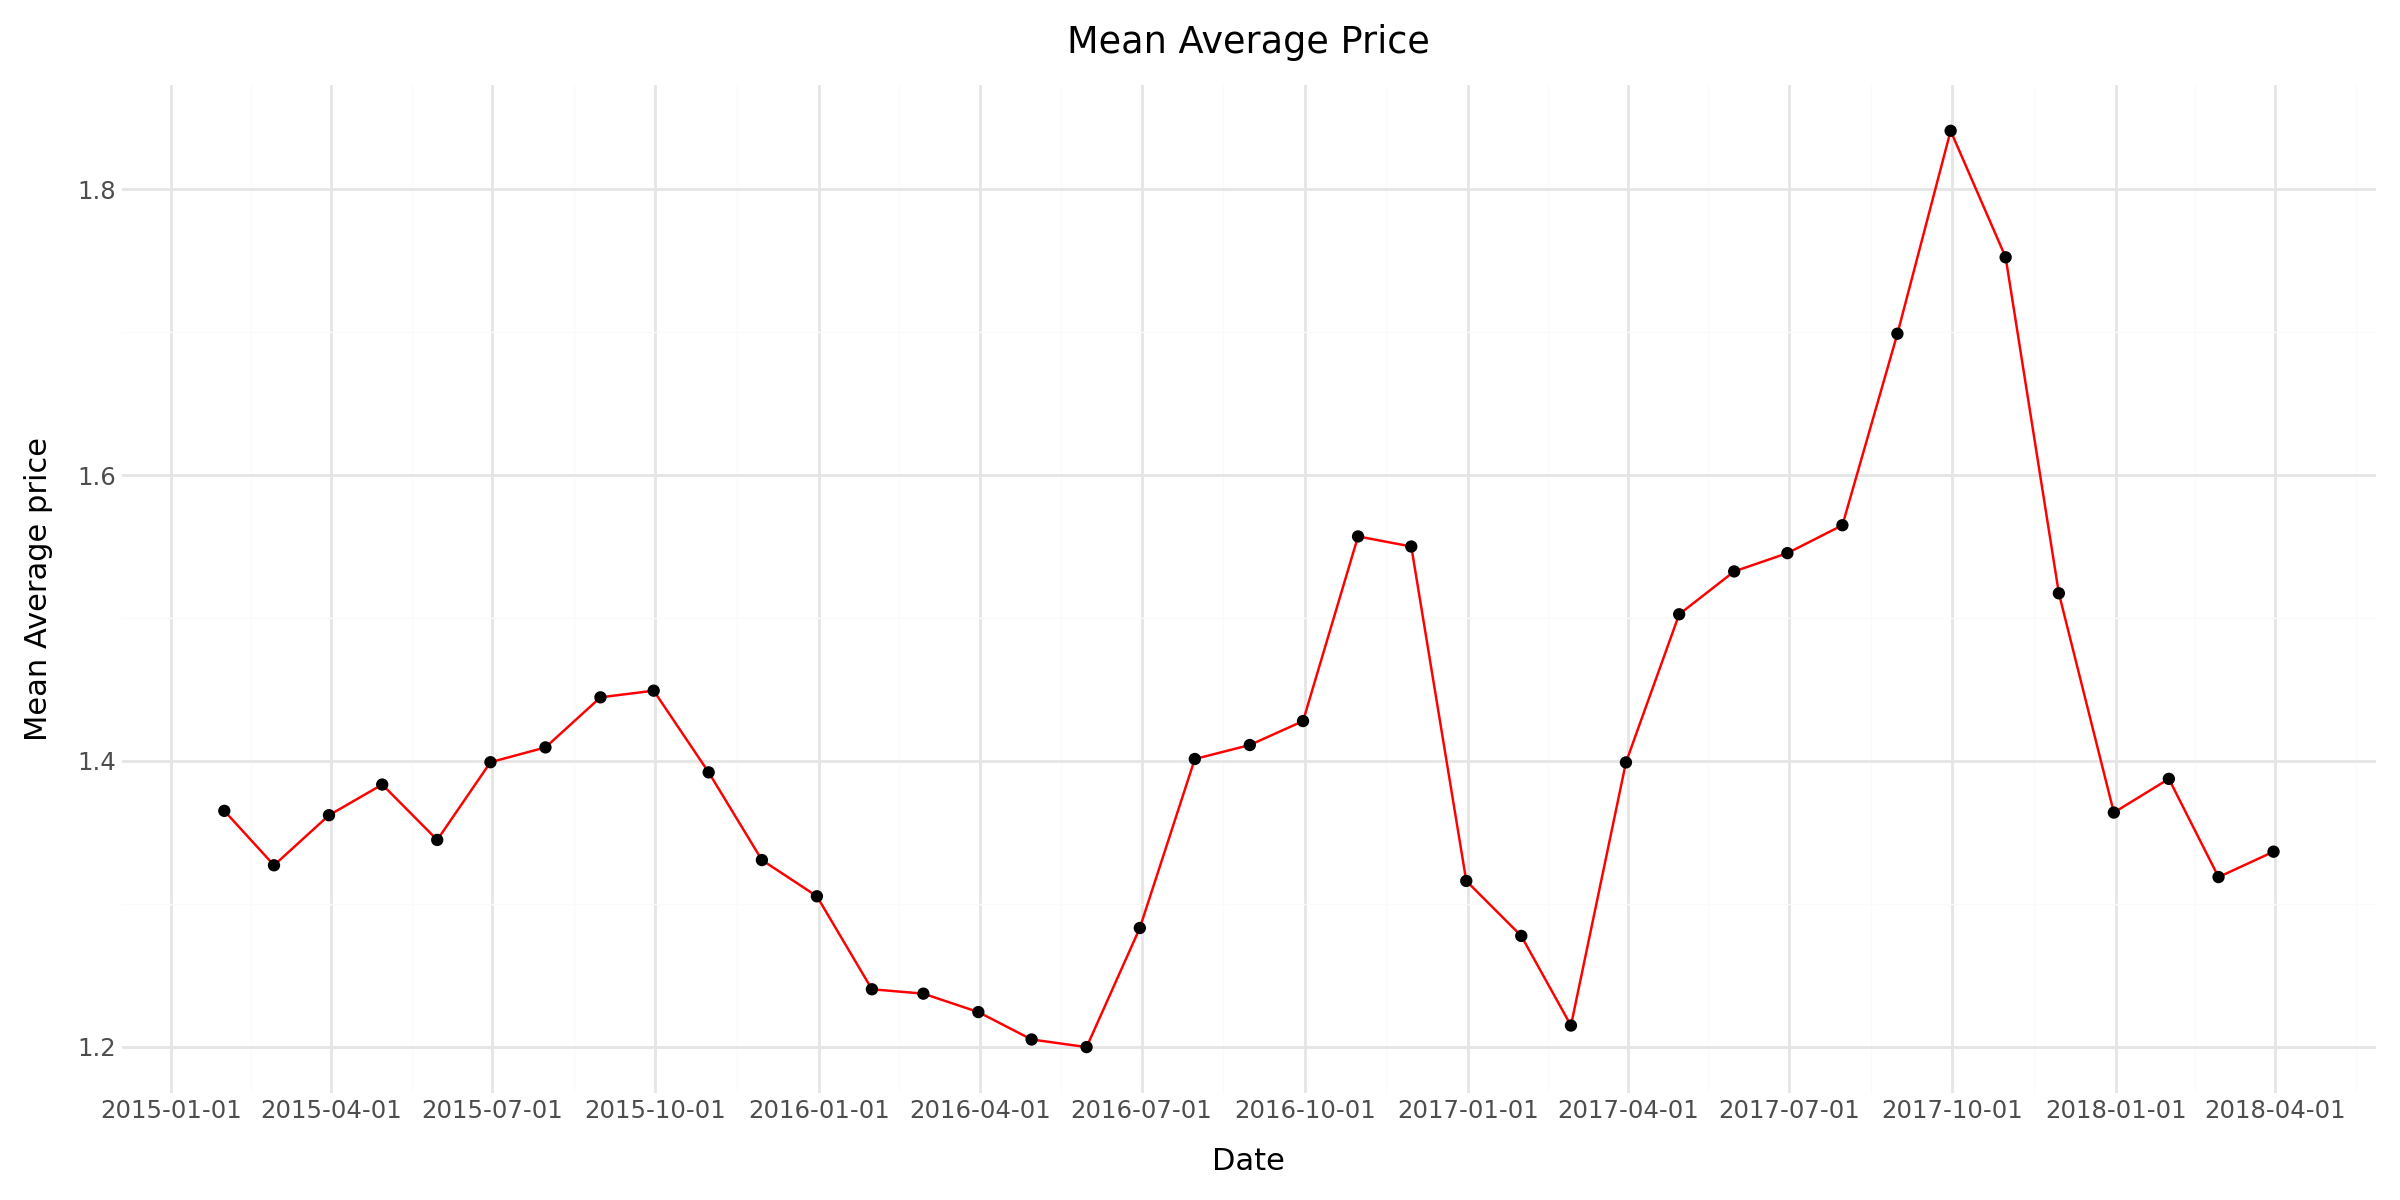

In [458]:
(ggplot(date_price_df, aes('date', 'mean')) + geom_line(color = 'red')
 + geom_point()
 + theme_minimal()
 + scale_x_date(breaks = '3 months')
 + labs(x = 'Date', 
        y = 'Mean Average price',
        title = 'Mean Average Price')
+ theme(figure_size = (12, 6)))

**Plot Interpretation:** From the plot above, the data looks seasonal and there is a slight trend

#### **Linearity**

In [459]:
#Chceking for the relationship between this month and last month
date_price_df = date_price_df.set_index('date')
date_price_df['shift'] = date_price_df['mean'].shift(1)
date_price_df.head()

,mean,shift
date,,
2015-01-31,1.365046,NaN
2015-02-28,1.326944,1.365046
2015-03-31,1.361981,1.326944
2015-04-30,1.383449,1.361981
2015-05-31,1.344685,1.383449


c:\Users\HomePC\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\plotnine\stats\smoothers.py:342: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
c:\Users\HomePC\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning: geom_point : Removed 1 rows containing missing values.


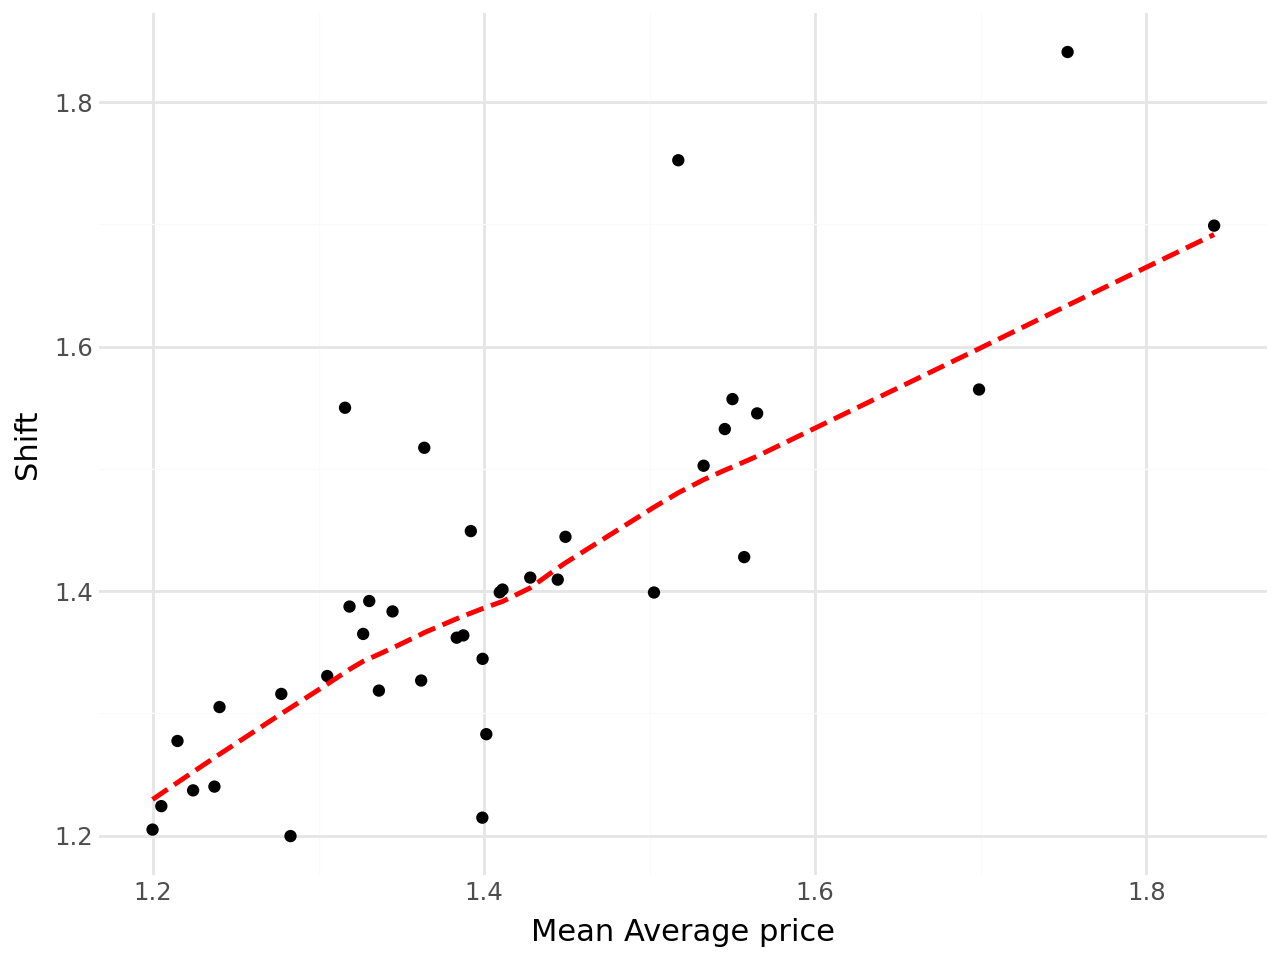

In [460]:
# Visualizing Linearity
(ggplot(date_price_df, aes('mean', 'shift'))
 + geom_point() 
 + geom_smooth(color = 'red', linetype = '--')
 + theme_minimal()
 + labs(x = 'Mean Average price', 
        y = 'Shift'))

**Plot Interpretation:** There is a linear relationship between last month average price of avocados and this month average price of avocados. Therefore, there is linearity between this month and last month.

#### **Checking for Stationarity**  

Null Hypothesis: This assumes that the time-series is not stationary

Alternate Hypothesis: If the null hypothesis is rejected, this assumes that the time series is stationary

In [461]:
#Checking for differencing to make te data stationary and remove trend
average_price_new = adfuller(date_price_df[['mean']])

print(pd.Series(average_price_new[0:5], index=['Test Statistic','p-value','Lags Used','Number of Observations Used', "Critical Value"]))

Test Statistic                                                         -2.986463
p-value                                                                 0.036178
Lags Used                                                                      1
Number of Observations Used                                                   37
Critical Value                 {'1%': -3.6209175221605827, '5%': -2.943539461...
dtype: object


This result indicates that the pvalue is 0.03 which is less than 0.05. Therefore we reject the null hypothesis. This means our data is Stationary (Constant Variance and Mean)

**Checking for the ACF and PACF plot**

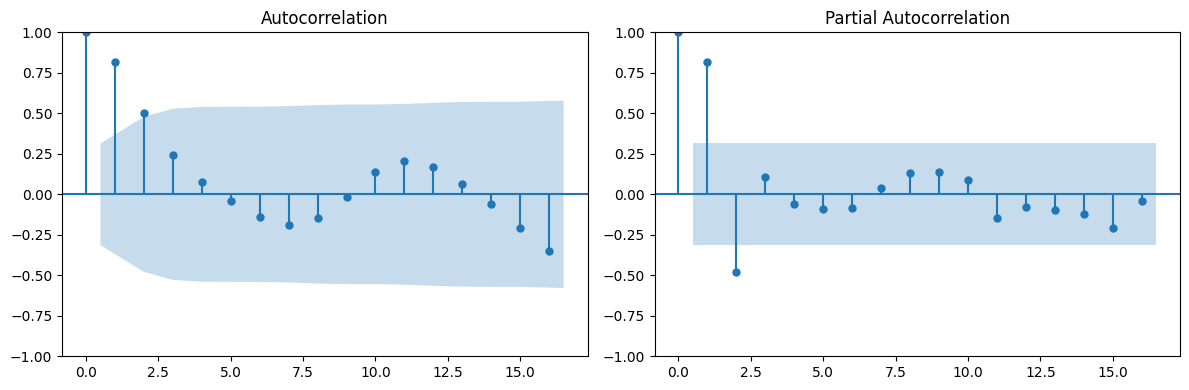

In [462]:
date_price_mean = date_price_df[['mean']]

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(date_price_mean, ax=axes[0])
plot_pacf(date_price_mean, ax=axes[1])
plt.tight_layout()
plt.show()

**Plot Interpretation:** The ACF (Autocorrelation) tails off i.e. there is a gradual decline and 2 lags are above the significant line. There is pattern and this shows there is seasonality in the data, we confirm from our seasonal decompose.  
The PACF (Partial Autocorrelation) cuts off.   
With these plots characteristics, we would use **AR model**

##### Decomposition

We are using the seasonal decompose

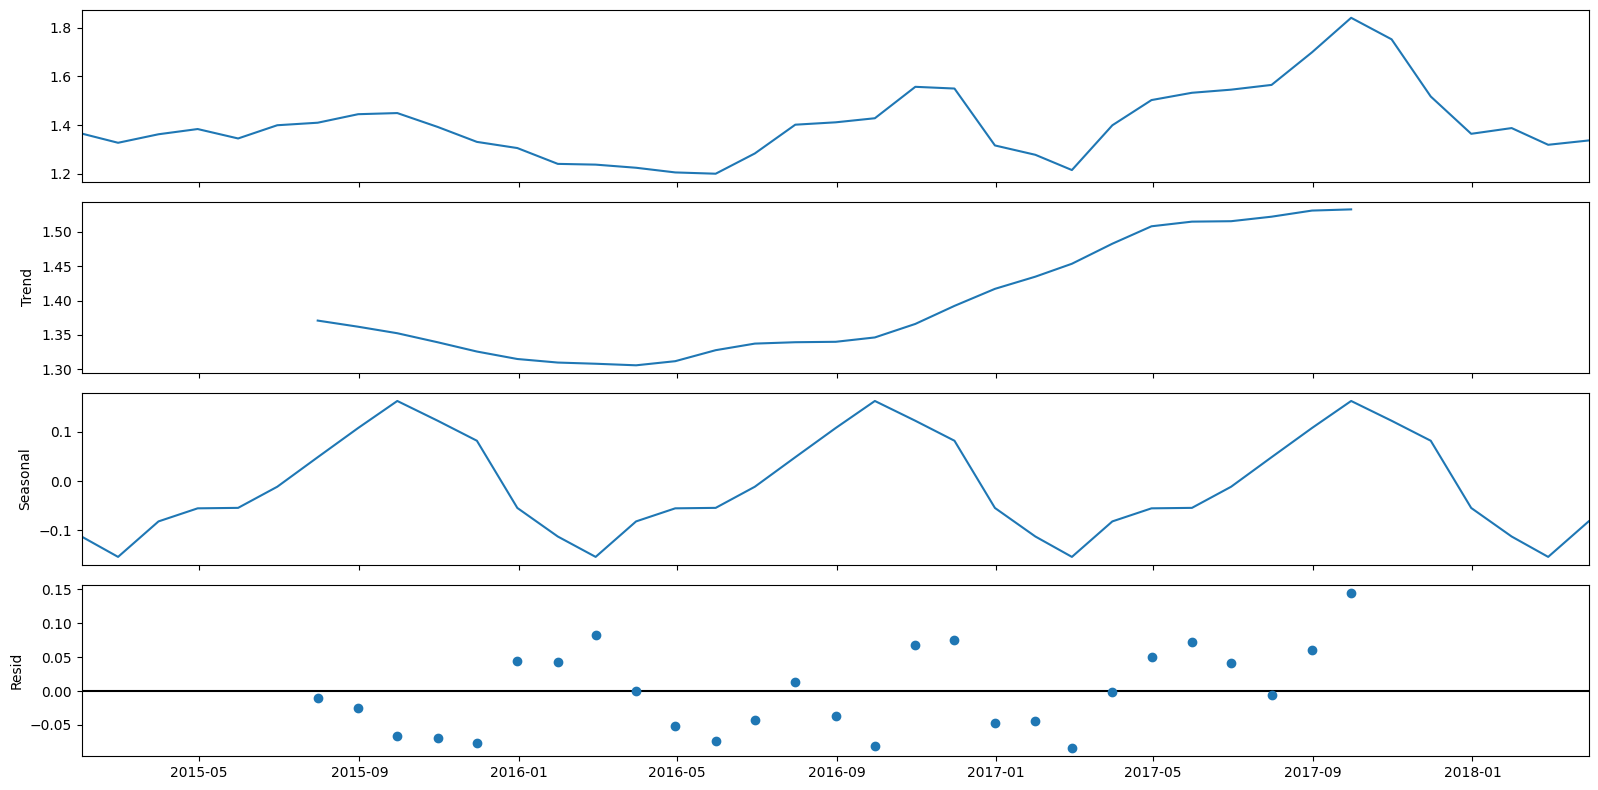

In [463]:
avg_price_season = seasonal_decompose(date_price_mean, period = 12)

avg_price_plot = avg_price_season.plot()

avg_price_plot.set_size_inches(16, 8)

avg_price_plot.tight_layout()

plt.show()

**Plot Interpretation:** The observed plot (top plot) increases overtime. The trend is increasing and there is seasonality (repeating patterns) in the data. The residuals are scattered and have a pattern.

##### Splitting and Training 

In [464]:
date_price_mean.head()

,mean
date,
2015-01-31,1.365046
2015-02-28,1.326944
2015-03-31,1.361981
2015-04-30,1.383449
2015-05-31,1.344685


In [465]:
date_price_mean = date_price_mean.sort_index()

avg_price_train = date_price_mean.loc[:'2017-07-31']
avg_price_test = date_price_mean.loc['2017-07-31':]
avg_price_train.head()

,mean
date,
2015-01-31,1.365046
2015-02-28,1.326944
2015-03-31,1.361981
2015-04-30,1.383449
2015-05-31,1.344685


In [466]:
sarima_1_model = SARIMAX(avg_price_train, order = (1,0,0), seasonal_order=(0, 0, 0, 12))
avg_price_ar = sarima_1_model.fit()

print(avg_price_ar.summary())

                               SARIMAX Results                                
Dep. Variable:                   mean   No. Observations:                   31
Model:               SARIMAX(1, 0, 0)   Log Likelihood                  33.614
Date:                Fri, 17 Apr 2026   AIC                            -63.227
Time:                        07:52:31   BIC                            -60.359
Sample:                    01-31-2015   HQIC                           -62.292
                         - 07-31-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9987      0.009    113.522      0.000       0.981       1.016
sigma2         0.0055      0.001      5.600      0.000       0.004       0.007
Ljung-Box (L1) (Q):                   1.63   Jarque-

c:\Users\HomePC\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
c:\Users\HomePC\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
c:\Users\HomePC\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.


In [467]:
sarima_2_model = SARIMAX(avg_price_train, order = (2,0,0), seasonal_order=(0, 0, 0, 12))
avg_price_ar_2 = sarima_2_model.fit()

print(avg_price_ar_2.summary())

c:\Users\HomePC\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
c:\Users\HomePC\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
c:\Users\HomePC\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.


                               SARIMAX Results                                
Dep. Variable:                   mean   No. Observations:                   31
Model:               SARIMAX(2, 0, 0)   Log Likelihood                  34.539
Date:                Fri, 17 Apr 2026   AIC                            -63.078
Time:                        07:52:31   BIC                            -58.776
Sample:                    01-31-2015   HQIC                           -61.676
                         - 07-31-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.2401      0.258      4.809      0.000       0.735       1.745
ar.L2         -0.2416      0.256     -0.943      0.346      -0.744       0.261
sigma2         0.0052      0.001      5.976      0.0

**Interpretation**: 

Both SARIMAX(1,0,0) and SARIMAX(2,0,0) models were fitted to the training dataset. The models produced similar AIC values, indicating comparable performance. In both cases, the AR1 lag was statistically significant, suggesting weak autoregressive structure in the data. However, the lag 2 wasn't

The AIC is lesser in lag 1 than lag 2  
The BIC is is lesser in lag 1 than lag 2  
The Ljung-Box probability is greater than the significance level which means that we fail to reject null hypothesis. Therefore there is no autocorrelation in the errors.

The Heteroscedascity is significant because our errors don't have constant variance. We reject the null hypothesis.

The arima_model_1 is better in predicting the average price.

**Forecast**

In [468]:
price_predict_train = avg_price_ar.predict(start=avg_price_train.index[0],
                                 end=avg_price_train.index[-1],
                                 dynamic = False)

price_predict_train = price_predict_train.reset_index()
price_predict_train.head()

,index,predicted_mean
0,2015-01-31,0.000000
1,2015-02-28,1.363289
2,2015-03-31,1.325236
3,2015-04-30,1.360228
4,2015-05-31,1.381668


In [469]:
price_train2 = avg_price_train.reset_index()
price_predict_train["mean"] = price_train2["mean"]
price_predict_train.head()

,index,predicted_mean,mean
0,2015-01-31,0.000000,1.365046
1,2015-02-28,1.363289,1.326944
2,2015-03-31,1.325236,1.361981
3,2015-04-30,1.360228,1.383449
4,2015-05-31,1.381668,1.344685


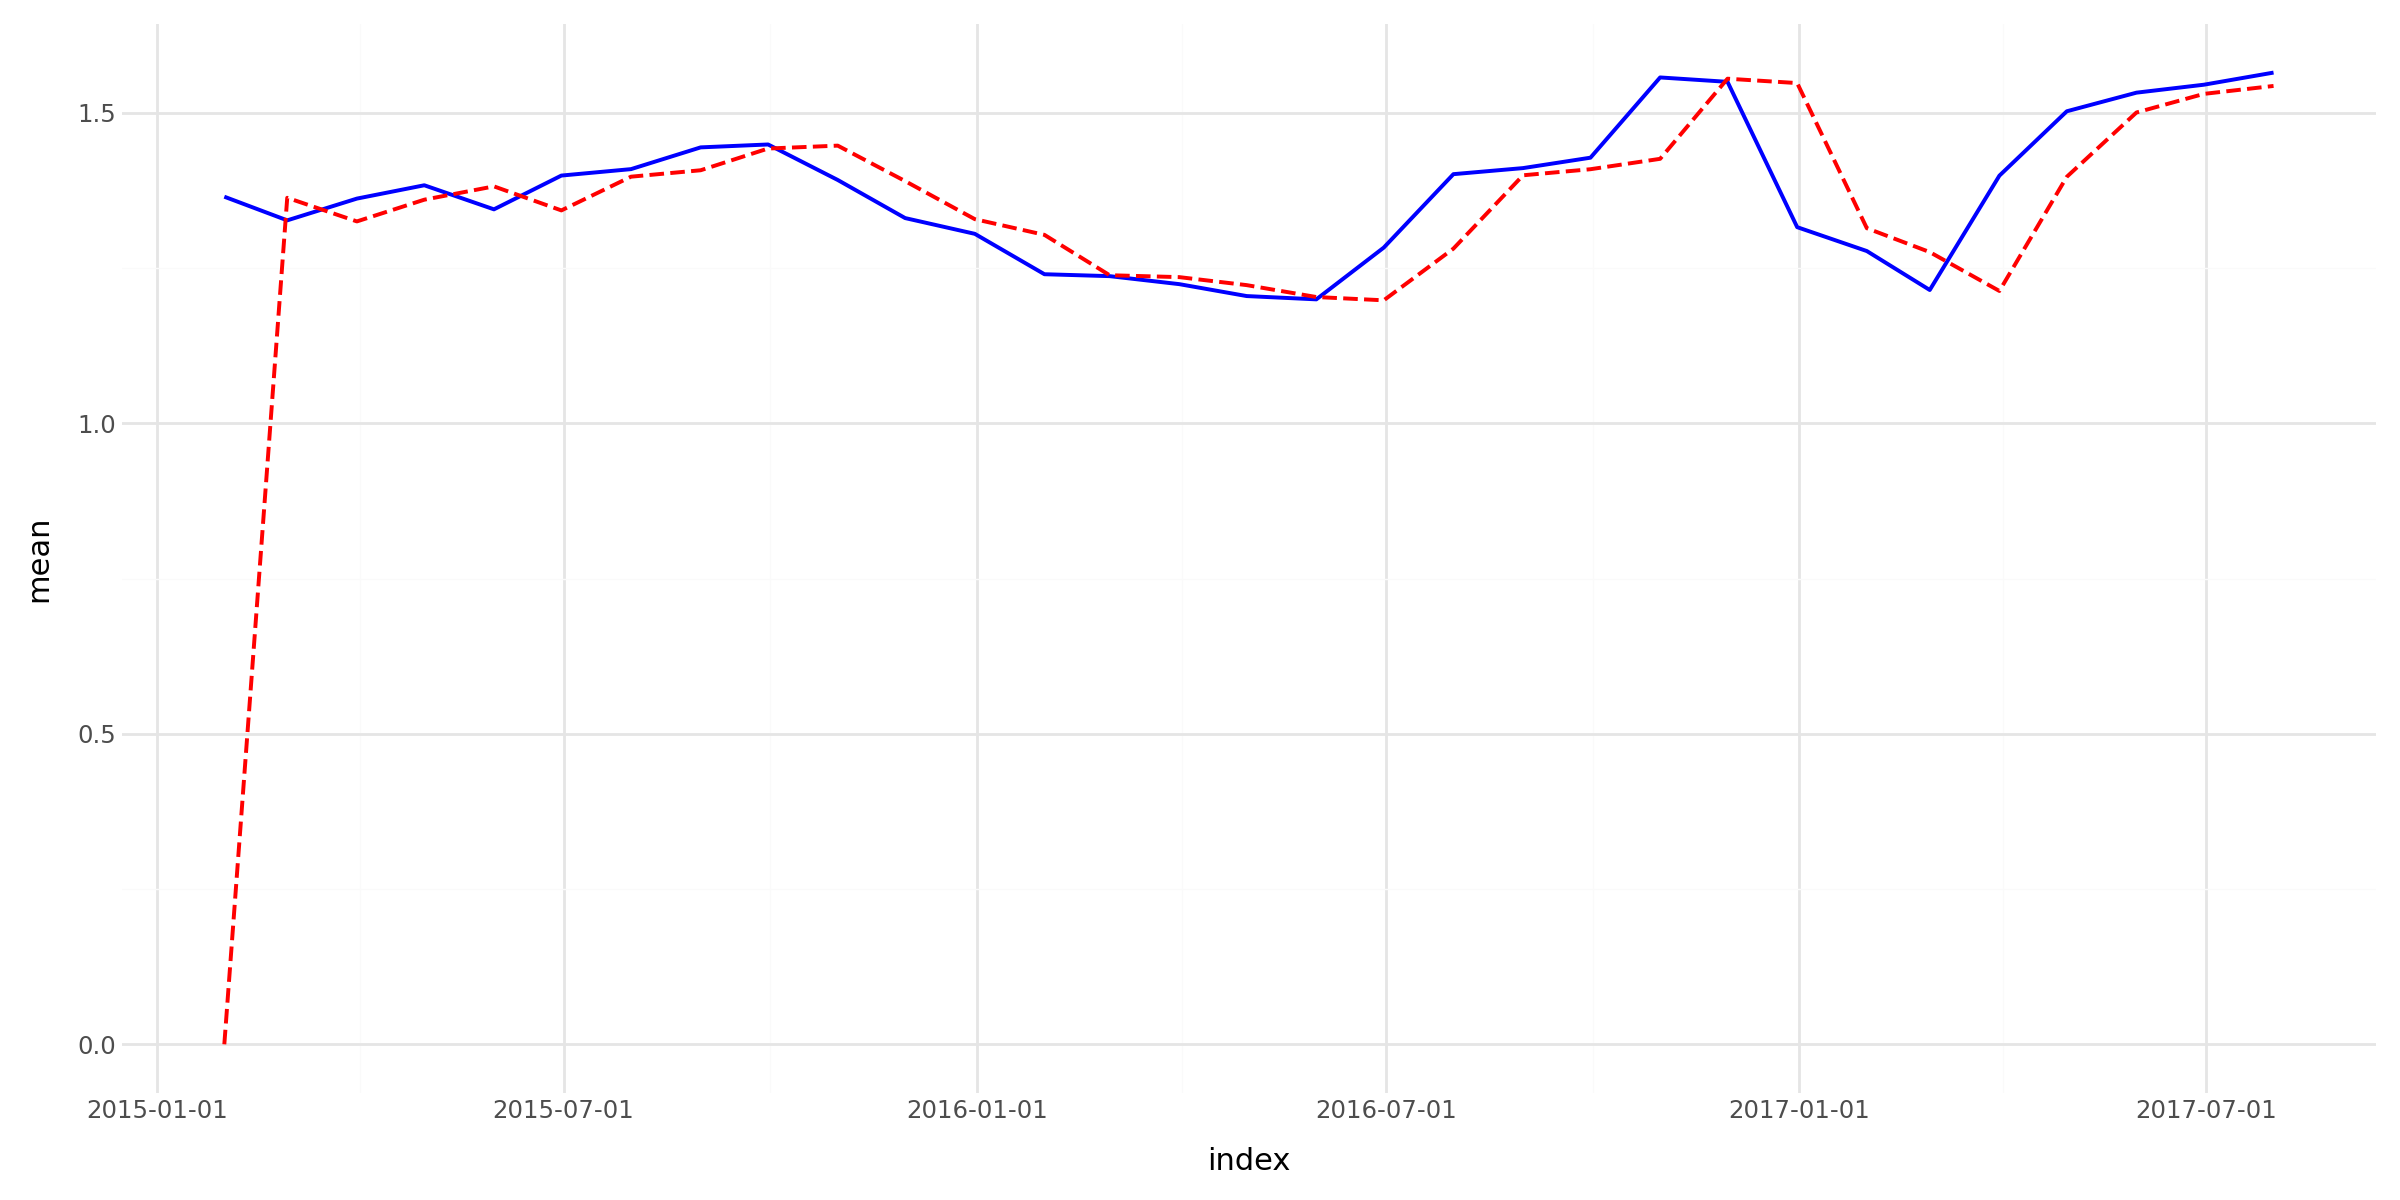

In [470]:
#Plot of predicted vs actual mean
(ggplot(price_predict_train, aes("index", "mean"))
+ geom_line(color = "blue", size = 0.8)
+ geom_line(price_predict_train, aes("index", "predicted_mean"), color = "red", size = 0.8, linetype = "--") 
+ theme_minimal()
+ theme(figure_size = (12, 6))
+ labs(title = ""))

**Evaluation**

In [471]:
mse_time = mean_squared_error(price_predict_train["mean"], price_predict_train["predicted_mean"])
print(mse_time)

rmse_time = np.sqrt(mse_time)
rmse_time

0.06547642219884885


np.float64(0.255883610649156)

**Model Comparison**

In [472]:
linear_df = pd.DataFrame([rmse_l, mse_l], columns= ['Evaluation Metrics Linear'], index = ['rmse', 'mse'])
time_df = pd.DataFrame([rmse_time, mse_time], columns= ['Evaluation Metrics Time'], index = ['rmse', 'mse'])
comparison_df = pd.concat([linear_df, time_df], axis = 1)
display(comparison_df)


,Evaluation Metrics Linear,Evaluation Metrics Time
rmse,0.315851,0.255884
mse,0.099762,0.065476


Comparing both model scores, We are using the Time series to predict, it has better rmse score and the model is off by a little compared to linear regression.

#### Predicting with Test Data

In [480]:
prices_predict = avg_price_ar.predict(start=avg_price_test.index[0],
                                 end=avg_price_test.index[-1],
                                 dynamic = False)

prices_predict = prices_predict.reset_index()

avg_price_test = avg_price_test.reset_index()
prices_predict["mean"] = avg_price_test["mean"]
prices_predict.head()



,index,predicted_mean,mean
0,2017-07-31,1.543406,1.564926
1,2017-08-31,1.562911,1.698958
2,2017-09-30,1.560900,1.840949
3,2017-10-31,1.558890,1.752444
4,2017-11-30,1.556884,1.517292


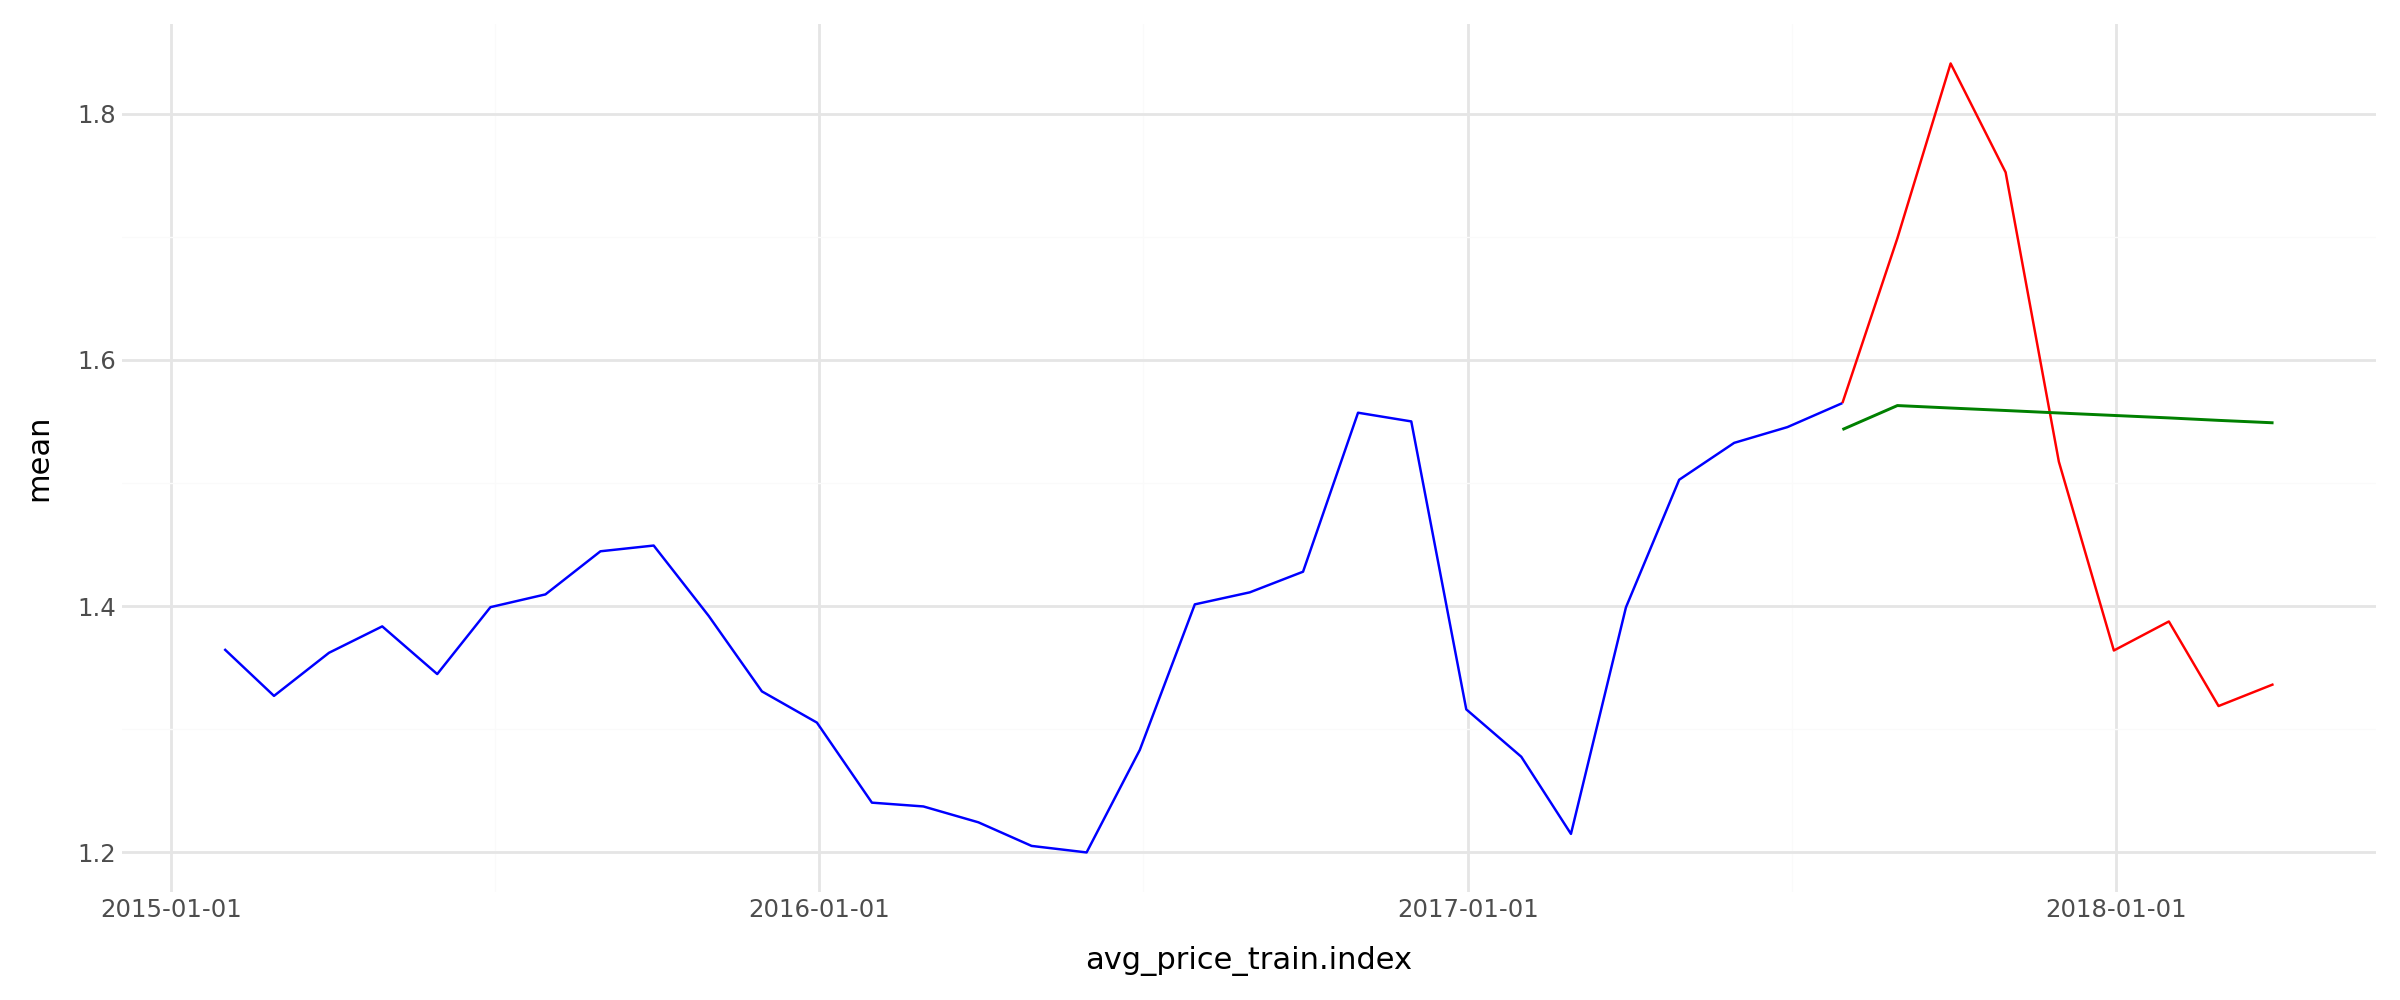

In [474]:
#Plot of predicted vs Actual Test and training data
(ggplot(avg_price_train, aes("avg_price_train.index", "mean"))
+ geom_line(color = "blue")
+ geom_line(avg_price_test, aes("avg_price_test.index", "mean"), color = "red") 
+ geom_line(prices_predict, aes("index", "predicted_mean"), color = "green", size = 0.6) 
+ theme_minimal()
+ theme(figure_size = (12, 5)))


**Residuals**

In [481]:
prices_predict["residuals"] = prices_predict["mean"] - prices_predict["predicted_mean"]

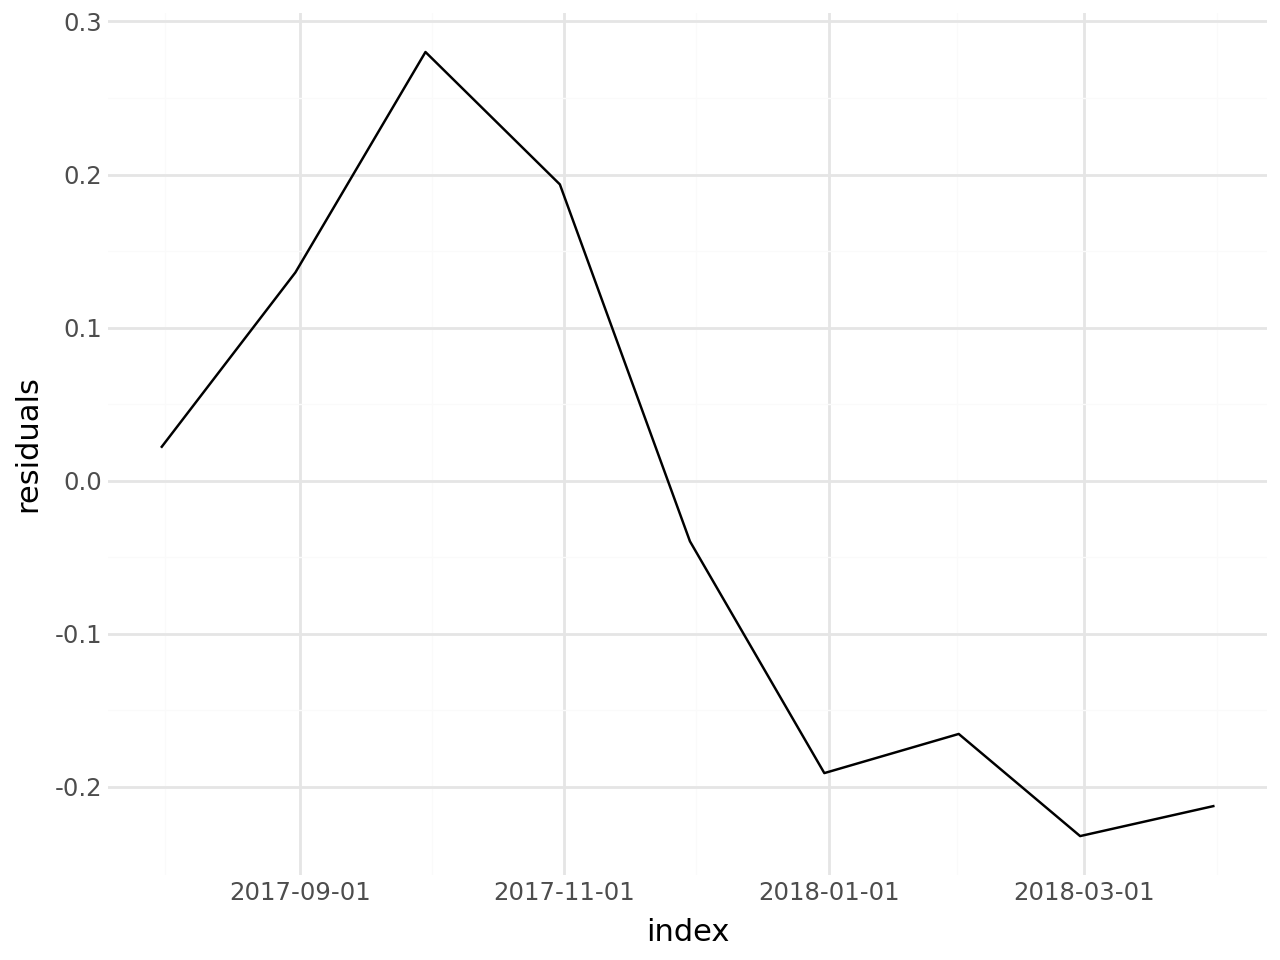

In [482]:
(ggplot(prices_predict, aes("index", "residuals"))
+ geom_line()
+ theme_minimal() 
) #some dynamic not captured by our model

**Key drivers of avocado prices**  
- The analysis shows that time (seasonality), the type of avocado and the total volume are the key drivers of avocado prices.

------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# Part 2: Avocado Type Classification using PCA and Logistic Regression Classification

Seeing that the independent variables (features) are strongly correlated, we are applying PCA to our data to reduce the noise as well as capturing most part of our data.

##### Data Preprocessing

In [ ]:
#changing the encoded type column to a categorical column
avocado1['type_no'] = avocado1['type_no'].astype('category')

#Selecting the independent and target variables
X = avocado1.drop(['type_no', 'type', 'date', 'region', 'month'], axis = 1)
y = avocado1['type_no']

#Splitting into our testing and training set 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Standardizing before PCA
sca = StandardScaler()

#Fitting and transforming the train and test set
X_train_scaled = sca.fit_transform(X_train)
X_test_scaled = sca.transform(X_test)

#Converting to a dataframe
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns= X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns= X.columns)

#Initiating the PCA model, fit then transform
pca1 = PCA()
pca1.fit(X_train_scaled_df)
X_train_pca = pca1.transform(X_train_scaled_df)

#Converting to a Dataframe
X_train_pca_df = pd.DataFrame(X_train_pca, columns= X.columns)

In [ ]:
explained_variance = pca1.explained_variance_ratio_

eigenvalues = pca1.explained_variance_

ev_df = pd.DataFrame({'explained_variance': explained_variance,
                         'values': range(1, 11)})

eigen_df= pd.DataFrame({"values": range(1, 11),
                       "eigenvalue": eigenvalues}) 

eigen_df


,values,eigenvalue
0,1,7.032154e+00
1,2,1.100335e+00
2,3,8.848233e-01
3,4,3.956646e-01
4,5,3.414197e-01
5,6,1.323671e-01
6,7,7.033697e-02
7,8,4.358388e-02
8,9,1.860477e-10
9,10,3.043784e-15


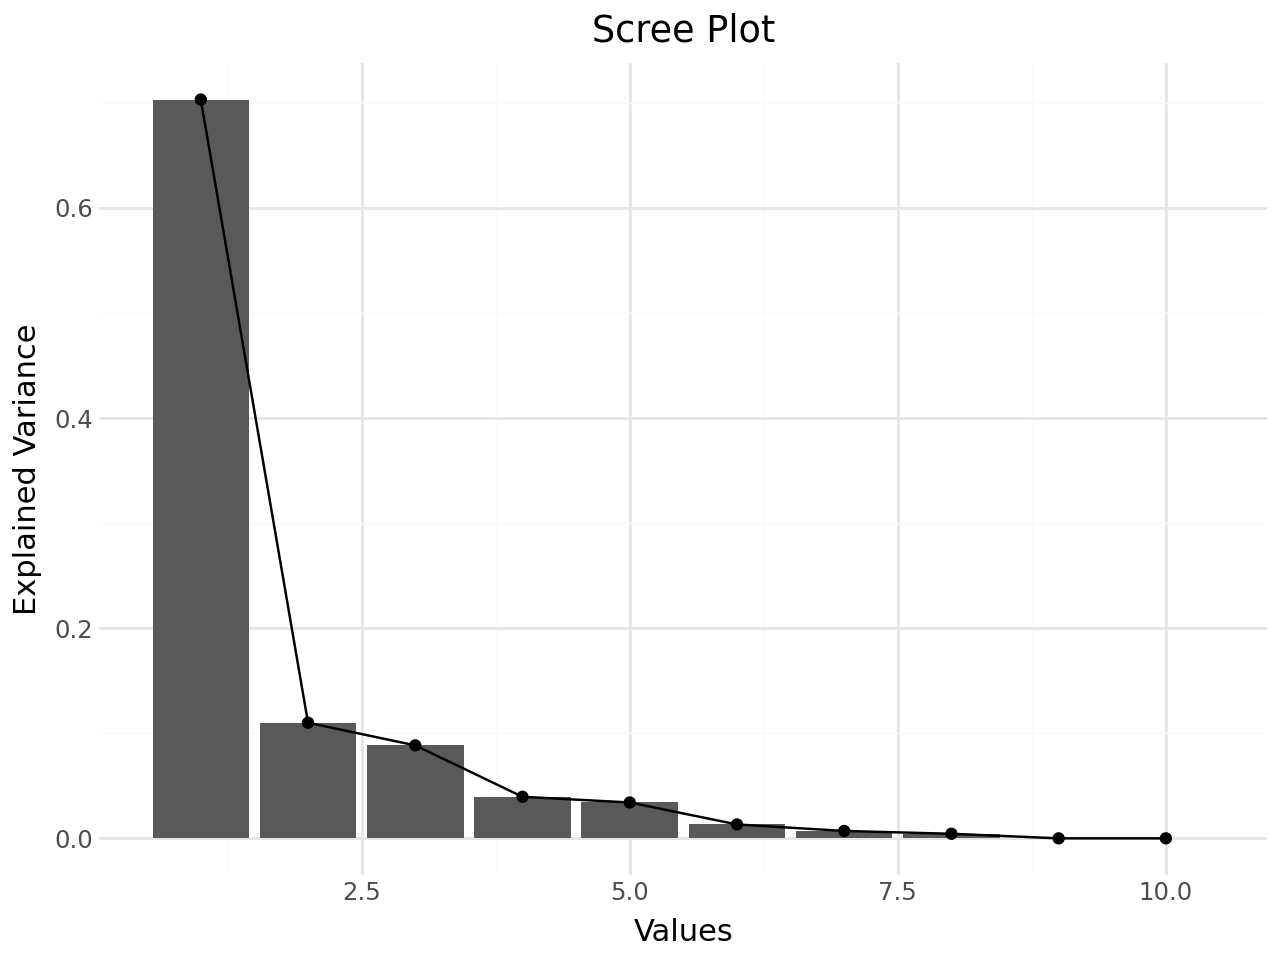

In [ ]:
#Visualizing with a Scree plot
(ggplot(ev_df, aes('values', 'explained_variance')) + geom_col()
 + geom_point()
 + geom_line()
 + theme_minimal()
 + labs(x = 'Values',
        y = 'Explained Variance',
        title = 'Scree Plot'))

**PLOT INTERPRETATION**: USING THE KAISER RULE, SELECTING THE COMPONENTS THAT HAVE EIGENVALUES GREATER THAN 1 -- THE FIRST 2 COMPONENTS; n=2  
ALSO USING THE ELBOW METHOD FROM THE SCREE PLOT, THE ELBOW POINT IS AROUND PCA 2, THEREFORE n = 2

In [ ]:
#Initiating a new PCA model with the number of components specified, fit then transformed
pca2 = PCA(n_components=2)
pca2.fit(X_train_scaled_df)
X_train_pca2 = pca2.transform(X_train_scaled_df)

print(f'The pca2 model explains {pca2.explained_variance_ratio_.sum() * 100.:2f}% of the data')

X_train_pca2_df = pd.DataFrame({'pca1': X_train_pca2[:, 0], 
                                'pca2': X_train_pca2[:, 1]})

X_train_pca2_df['target'] = avocado1['type_no']

The pca2 model explains 81.319324% of the data


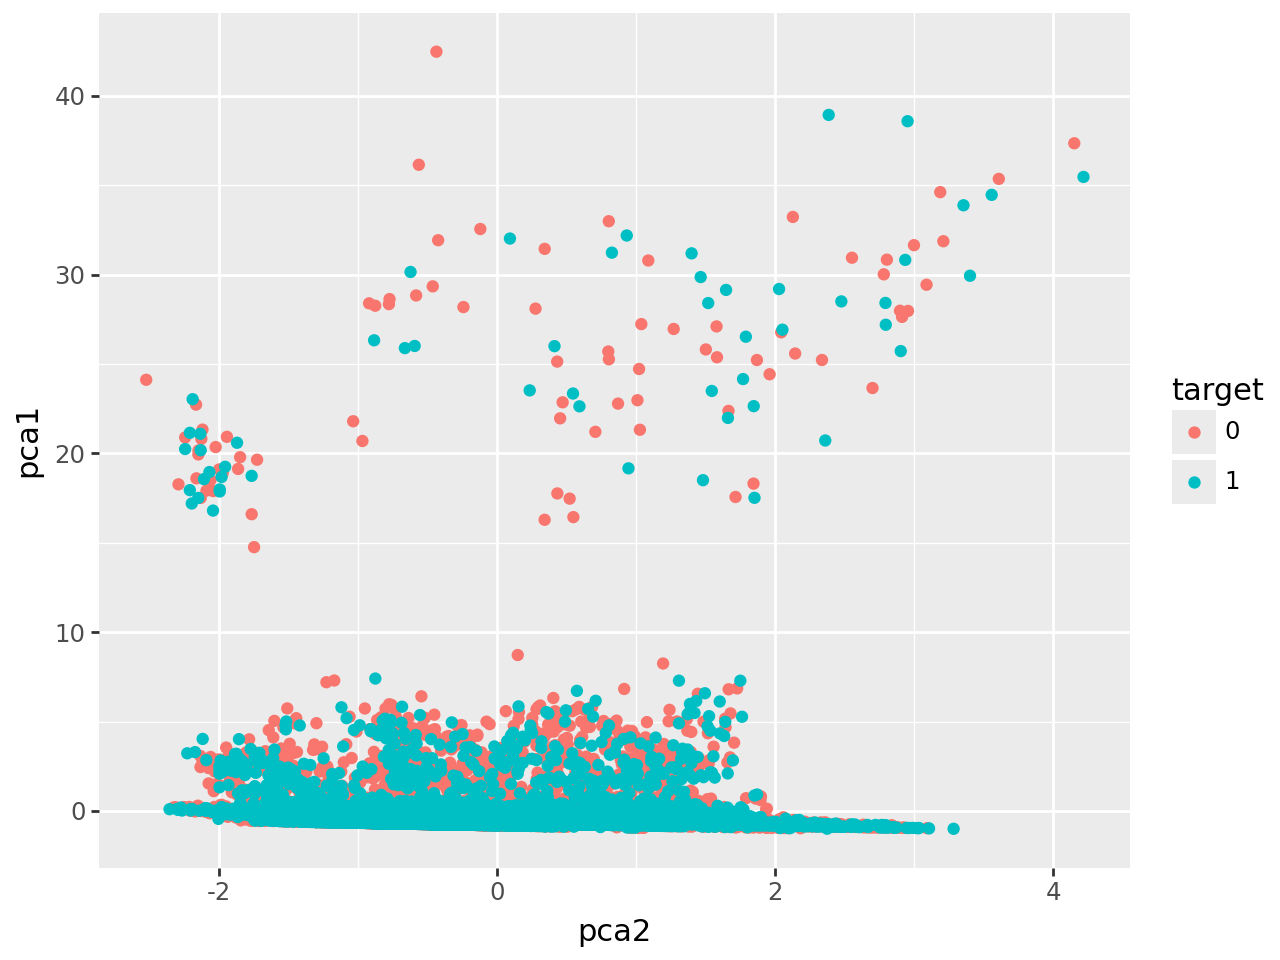

In [ ]:
#Plotting the PCA1 and PCA2
(ggplot(X_train_pca2_df, aes('pca2', 'pca1', color = 'target')) + geom_point())

**Plot Interpretation:** The target points are overlapping and there are no obvious clusters. However, they capture and explain about 81% of the data.

In [ ]:
#Initiating the Logistic Regression model and fit
lr_model = LogisticRegression()
lr_model.fit(X_train_pca2_df[['pca1', 'pca2']], y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
#Log-odds
coefficient = lr_model.coef_
display(coefficient)

#Odds
odds = np.exp(coefficient)
odds

array([[-11.74377669,   0.48856534]])

array([[7.93857563e-06, 1.62997608e+00]])

In [ ]:
#Intercept of our model
intercept = lr_model.intercept_
intercept

array([-5.98107283])

In [ ]:
#Predicting our training data
predicted_type = lr_model.predict(X_train_pca2_df[['pca1', 'pca2']])

#Evaluating the model
print("\n Classification report for classifier %s:\n%s\n"
      % (lr_model, classification_report(y_train, predicted_type)))



 Classification report for classifier LogisticRegression():
              precision    recall  f1-score   support

           0       0.92      0.87      0.90      7306
           1       0.88      0.93      0.90      7293

    accuracy                           0.90     14599
   macro avg       0.90      0.90      0.90     14599
weighted avg       0.90      0.90      0.90     14599




#### Testing the model

In [ ]:
X_test_pca = pca2.transform(X_test_scaled_df)
X_test_pca_df = pd.DataFrame({'pca1': X_test_pca[:, 0],
                              'pca2': X_test_pca[:, 1]})


In [ ]:
y_pred_pca = lr_model.predict(X_test_pca)

#Evaluating the predicted models
print("\n Classification report for classifier %s:\n%s\n"
      % (lr_model, classification_report(y_test, y_pred_pca)))


 Classification report for classifier LogisticRegression():
              precision    recall  f1-score   support

           0       0.93      0.86      0.89      1820
           1       0.87      0.93      0.90      1830

    accuracy                           0.90      3650
   macro avg       0.90      0.90      0.90      3650
weighted avg       0.90      0.90      0.90      3650




c:\Users\HomePC\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names


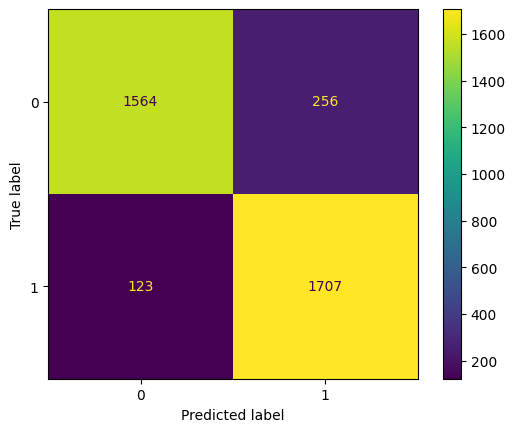

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_pca)
plt.show()

The Confusion matrix displays the relationship between the predicted & true label. The model did a fair job predicting with an accuracy score of 90% which uis good enough. 

**Testing the linear regression model on the test data:** The classification report showed that The model did a good job predicting.
- 1564 records were correctly predicted as Conventional Avocado type.  
- 123 records were incorrectly predicted as Conventional Avocado type
- 1707 records were correctly predicted as Organic Avocado type.  
- 256 records incorrectly predicted as Organic Avocado type.  
